# The Artificial Judge: ECHR Violation Prediction

**Project:** *Evaluating Legal Reasoning and Spurious Correlations in NLP Models of the European Court of Human Rights*

This notebook walks through the full modelling pipeline end-to-end:
1. Data loading (Original 3-country / v1 8-country)
2. TF-IDF + SVM / LogReg baseline
3. Document coverage analysis — why SVM beats 512-token BERT
4. SVM at different token budgets
5. LegalBERT 512-token fine-tuning (training code included)
6. LegalBERT chunked 4x sliding window (training code included)
7. Bias analysis

> **Key finding:** SVM's apparent superiority over fine-tuned BERT was entirely caused by input truncation.
> Restoring coverage via 4x chunked LegalBERT finally beats full-text SVM.

**Result loading priority (per model):**
1. Load from `logs/N.log` if available (pre-run training logs)
2. Load from saved `results/*.npz` probabilities
3. Run training from scratch (set `TRAIN_FROM_SCRATCH = True`, requires GPU)
4. Fall back to known values from training logs

In [1]:
# Install any missing dependencies
%pip install -q lime spacy seaborn
import subprocess, sys
subprocess.run([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm', '--quiet'],
               capture_output=True)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


CompletedProcess(args=['/home/gwwang/virtualenvs/workon310/bin/python', '-m', 'spacy', 'download', 'en_core_web_sm', '--quiet'], returncode=0, stdout=b"\x1b\xe2\x9c\x94 Download and installation successful\x1b\nYou can now load the package via spacy.load('en_core_web_sm')\n", stderr=b'\n\x1b[\x1b\x1bnotice\x1b\x1b[1;39;49m]\x1b\x1b A new release of pip is available: \x1b\x1b25.3\x1b\x1b -> \x1b\x1b26.0.1\x1b\n\x1b[\x1b\x1bnotice\x1b\x1b[1;39;49m]\x1b\x1b To update, run: \x1b\x1bpip install --upgrade pip\x1b\n')

In [2]:
%matplotlib inline
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup, set_seed as hf_set_seed,
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
warnings.filterwarnings('ignore')
print('All imports OK')

/home/gwwang/virtualenvs/workon310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK


## 1. Configuration

In [3]:
# ── Dataset: 'original' (436 Art.6 cases, 3 countries) or 'v1' (1205 cases, 8 countries) ──
DATASET            = 'original'
FORCE_RETRAIN = False  # set True to force retraining even if saved files exist

CONFIG = {
    'original': {
        'data_path':         'data/processed/processed.csv',
        'probs_lb512':       'results/legalbert_512_original/test_probs.npz',
        'log_lb512':         'results/legalbert_512_original/training.log',
        'probs_chunked':     'results/legalbert_chunked_original_final/test_probs.npz',
        'log_chunked':       'results/legalbert_chunked_original_final/training.log',
        'known_lb512_f1':    0.680,
        'known_chunked_f1':  0.748,
        'known_svm_full_f1': 0.726,
        # Long-context models only run on v1; not available for original
        'probs_longformer':    None,
        'probs_neobert':       None,
        'known_longformer_f1': None,
        'known_neobert_f1':    None,
        'label': 'Original (436 Art.6 cases, RUS/TUR/GBR)',
    },
    'v1': {
        'data_path':         'data_v1/processed/processed.csv',
        'probs_lb512':       'results/legalbert_512_v1/test_probs.npz',
        'log_lb512':         'results/legalbert_512_v1/training.log',
        'probs_chunked':     'results/legalbert_chunked_v1_final/test_probs.npz',
        'log_chunked':       'results/legalbert_chunked_v1_final/training.log',
        'known_lb512_f1':    0.678,
        'known_chunked_f1':  0.760,
        'known_svm_full_f1': 0.725,
        # Legal-Longformer (lexlms/legal-longformer-base, 4096 tok, lr=1e-5, 8ep, 4-seed ens)
        'probs_longformer':    'results/legal_longformer_v2/test_probs.npz',
        'known_longformer_f1': 0.690,
        # NeoBERT (chandar-lab/NeoBERT, 250M params, 4096 tok, LLRD, 4-seed ens)
        'probs_neobert':       'results/neobert_v2/test_probs.npz',
        'known_neobert_f1':    0.693,
        'label': 'Enlarged v1 (1205 Art.6 cases, 8 countries)',
    },
}

# Training hyperparameters
HP = dict(
    model_name  = 'nlpaueb/legal-bert-base-uncased',
    seeds       = [0, 1, 2, 42],
    epochs      = 5,
    batch_size  = 8,
    lr          = 2e-5,
    wd          = 0.01,
    llrd_decay  = 0.90,
    focal_gamma = 2.0,
    max_len     = 512,
    n_head      = 128,
    chunk_size  = 510,
    n_chunks    = 4,
)

cfg  = CONFIG[DATASET]
SEED = 42

# ── Global seed fixing — ensures reproducible splits, LIME sampling, and training ──
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
os.environ['PYTHONHASHSEED'] = str(SEED)
hf_set_seed(SEED)

print(f'Dataset : {cfg["label"]}')
# ── Auto-detect whether training is needed ──────────────────────────────────
_lb512_ready   = os.path.exists(cfg['log_lb512'])   or os.path.exists(cfg['probs_lb512'])
_chunked_ready = os.path.exists(cfg['log_chunked']) or os.path.exists(cfg['probs_chunked'])
TRAIN_LB512   = FORCE_RETRAIN or not _lb512_ready
TRAIN_CHUNKED = FORCE_RETRAIN or not _chunked_ready

print(f'Dataset : {cfg["label"]}')
print(f'LegalBERT-512    : {"TRAIN" if TRAIN_LB512 else "skip (log/npz found)"}')
print(f'LegalBERT chunked: {"TRAIN" if TRAIN_CHUNKED else "skip (log/npz found)"}')
if FORCE_RETRAIN:
    print('FORCE_RETRAIN=True — will overwrite existing files.')
print(f'Global seed: {SEED}')


Dataset : Original (436 Art.6 cases, RUS/TUR/GBR)
Dataset : Original (436 Art.6 cases, RUS/TUR/GBR)
LegalBERT-512    : skip (log/npz found)
LegalBERT chunked: skip (log/npz found)
Global seed: 42


## 2. Log Discovery

Check which pre-run training logs are available. Logs are parsed to extract per-epoch validation F1 and final ensemble results — used for training curve plots and model comparison.

In [4]:
# ── Log parsing utilities ───────────────────────────────────────────────────

def parse_chunked_log(log_path):
    """
    Parse a train_chunked.py log file.
    Returns:
      seeds    : {seed_int: {'epochs': [{epoch, loss, val_f1}], 'test_f1': float}}
      ensemble : {'macro_f1': float, 'threshold': float}
      content  : raw log string
    """
    with open(log_path) as f:
        content = f.read()
    seeds, current = {}, None
    for line in content.split('\n'):
        m = re.search(r'Training with model seed=(\d+)', line)
        if m:
            current = int(m.group(1))
            seeds[current] = {'epochs': [], 'test_f1': None}
        m = re.search(r'Epoch (\d+)/\d+ \| loss=([\d.]+) \| val macro-F1=([\d.]+)', line)
        if m and current is not None:
            seeds[current]['epochs'].append(
                {'epoch': int(m.group(1)), 'loss': float(m.group(2)), 'val_f1': float(m.group(3))})
        m = re.search(r'seed=\d+ .+ test macro-F1: ([\d.]+)', line)
        if m and current is not None:
            seeds[current]['test_f1'] = float(m.group(1))
    m = re.search(r'macro_f1:\s+([\d.]+)\s+\(threshold=([\d.]+)\)', content)
    ensemble = {'macro_f1': float(m.group(1)), 'threshold': float(m.group(2))} if m else {}
    return seeds, ensemble, content


# ── Discover available logs ─────────────────────────────────────────────────
print(f'Checking logs for dataset: {DATASET}\n')

for label, path in [
    ('LegalBERT-512 log',    cfg['log_lb512']),
    ('LegalBERT chunked log', cfg['log_chunked']),
]:
    exists = os.path.exists(path)
    size   = os.path.getsize(path) if exists else 0
    status = f'FOUND  ({size:,} bytes)' if exists else 'not found'
    print(f'  [{status:30s}]  {path}')


Checking logs for dataset: original

  [FOUND  (635 bytes)            ]  results/legalbert_512_original/training.log
  [FOUND  (750 bytes)            ]  results/legalbert_chunked_original_final/training.log


## 3. Data Loading

All models use only the **FACTS section** of each ECHR judgment. Labels are Article-6-specific.

In [5]:
def contains_article(series, article):
    return series.fillna('').str.split(';').apply(
        lambda lst: any(a.strip() == article for a in lst)
    )

df = pd.read_csv(cfg['data_path'])
mask = (contains_article(df['violation_articles'], '6') |
        contains_article(df['nonviolation_articles'], '6'))
df   = df[mask].copy()
df['label']   = contains_article(df['violation_articles'], '6').astype(int)
df['n_words'] = df['text'].fillna('').str.split().str.len()

print(f'Cases: {len(df)}  |  Violation rate: {df["label"].mean():.1%}')
print(f'Countries: {sorted(df["respondent"].unique())}')
print(f'Year range: {int(df["year"].min())} - {int(df["year"].max())}')

train_val, test_df = train_test_split(df, test_size=0.25, stratify=df['label'], random_state=SEED)
train_df,  val_df  = train_test_split(train_val, test_size=0.15/0.75,
                                       stratify=train_val['label'], random_state=SEED)

X_train = train_df['text'].fillna('').tolist()
X_val   = val_df['text'].fillna('').tolist()
X_test  = test_df['text'].fillna('').tolist()
y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values
print(f'\nTrain: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

Cases: 436  |  Violation rate: 73.4%
Countries: ['GBR', 'RUS', 'TUR']
Year range: 1983 - 2026

Train: 261  Val: 66  Test: 109


## 4. TF-IDF Baselines: SVM and LogReg

The **legal tokenizer** is ported from `EDA.ipynb` for consistency: WordNet lemmatizer + legal stop words.

If the SVM log file exists, it is printed and results are parsed. Otherwise TF-IDF is trained live.

In [6]:
MANUAL_LEMMA_MAP = {
    'authorities': 'authority', 'applicants': 'applicant',
    'proceedings': 'proceeding', 'rights': 'right',
    'violations': 'violation',  'articles': 'article',
}
LEGAL_STOP = set(stopwords.words('english')) | {'court', 'case', 'mr', 'mrs', 'ms'}
wnl = WordNetLemmatizer()

def legal_tokenizer(text):
    tokens = [t for t in text.lower().split() if t.isalpha() and t not in LEGAL_STOP]
    return [MANUAL_LEMMA_MAP.get(t, wnl.lemmatize(t, pos='n')) for t in tokens]

TFIDF_PARAMS = dict(
    tokenizer=legal_tokenizer, token_pattern=None, lowercase=False,
    min_df=3, max_df=0.90, sublinear_tf=True, ngram_range=(1, 2)
)

def fit_eval(name, clf, xtr=None, xte=None, ytr=None, yte=None):
    xtr = xtr if xtr is not None else X_train
    xte = xte if xte is not None else X_test
    ytr = ytr if ytr is not None else y_train
    yte = yte if yte is not None else y_test
    pipe = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)), ('clf', clf)])
    pipe.fit(xtr, ytr)
    pred = pipe.predict(xte)
    mf1 = f1_score(yte, pred, average='macro')
    f1s = f1_score(yte, pred, average=None, labels=[0, 1])
    print(f'  {name:<32} macro-F1={mf1:.3f}  F1(NV)={f1s[0]:.3f}  F1(V)={f1s[1]:.3f}  acc={accuracy_score(yte,pred):.3f}')
    return pipe, pred, mf1

# TF-IDF models always run live (fast — seconds on CPU)
print('Training TF-IDF models...')
_,        dummy_pred, dummy_f1  = fit_eval('Dummy (majority class)',    DummyClassifier(strategy='most_frequent'))
svm_pipe, svm_pred,  svm_f1    = fit_eval('TF-IDF + SVM (full text)',  LinearSVC(C=0.1, class_weight='balanced', max_iter=3000))
lr_pipe,  lr_pred,   lr_f1     = fit_eval('TF-IDF + LogReg (full)',    LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000))


Training TF-IDF models...
  Dummy (majority class)           macro-F1=0.423  F1(NV)=0.000  F1(V)=0.847  acc=0.734
  TF-IDF + SVM (full text)         macro-F1=0.718  F1(NV)=0.606  F1(V)=0.829  acc=0.761
  TF-IDF + LogReg (full)           macro-F1=0.721  F1(NV)=0.603  F1(V)=0.839  acc=0.771


## 5. Document Coverage Analysis

BERT is hard-capped at 512 tokens. Most ECHR FACTS sections are longer.
Hypothesis: **SVM wins not because it is a better model, but because it reads the whole document.**

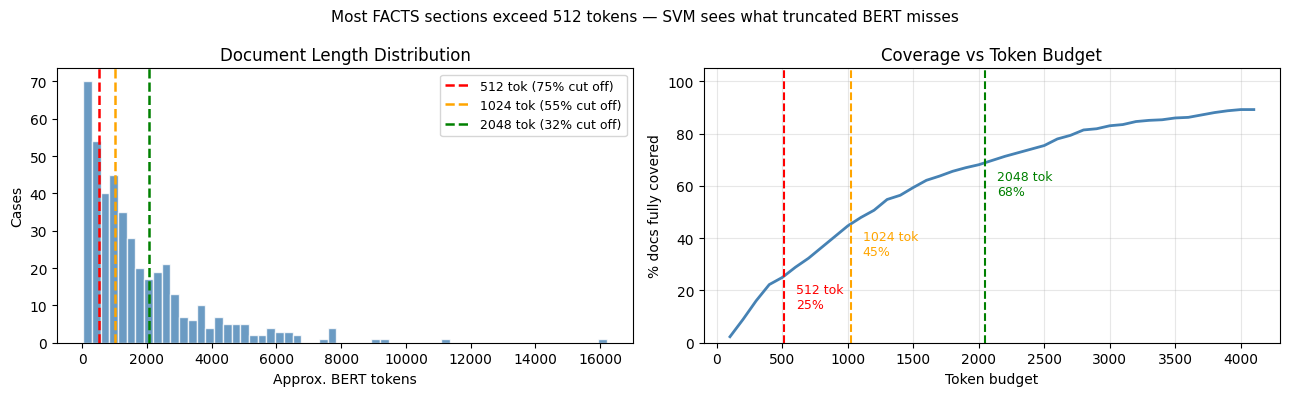

Median: ~1186 tokens  |  Mean: ~1774 tokens
  > 512 tokens: 74.5% of cases
  > 1024 tokens: 54.6% of cases
  > 2048 tokens: 31.7% of cases


In [7]:
bert_approx = df['n_words'] * 1.3

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.hist(bert_approx, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
for t, c in zip([512, 1024, 2048], ['red', 'orange', 'green']):
    ax.axvline(t, color=c, lw=1.8, ls='--', label=f'{t} tok ({(bert_approx>t).mean():.0%} cut off)')
ax.set_xlabel('Approx. BERT tokens'); ax.set_ylabel('Cases')
ax.set_title('Document Length Distribution'); ax.legend(fontsize=9)

ax2 = axes[1]
budgets  = list(range(100, 4200, 100))
coverage = [(bert_approx <= b).mean() * 100 for b in budgets]
ax2.plot(budgets, coverage, color='steelblue', lw=2)
for t, c in zip([512, 1024, 2048], ['red', 'orange', 'green']):
    pct = (bert_approx <= t).mean() * 100
    ax2.axvline(t, color=c, lw=1.5, ls='--')
    ax2.annotate(f'{t} tok\n{pct:.0f}%', xy=(t, pct), xytext=(t+90, pct-12), fontsize=9, color=c)
ax2.set_xlabel('Token budget'); ax2.set_ylabel('% docs fully covered')
ax2.set_title('Coverage vs Token Budget'); ax2.set_ylim(0, 105); ax2.grid(alpha=0.3)

plt.suptitle('Most FACTS sections exceed 512 tokens — SVM sees what truncated BERT misses', fontsize=11)
plt.tight_layout(); plt.show()

print(f'Median: ~{bert_approx.median():.0f} tokens  |  Mean: ~{bert_approx.mean():.0f} tokens')
for t in [512, 1024, 2048]:
    print(f'  > {t} tokens: {(bert_approx > t).mean():.1%} of cases')

## 6. SVM at Different Token Budgets

Restrict SVM to exactly the tokens BERT sees, scaling up from 512 to full text.
If SVM collapses at 512 tokens, **coverage — not the model — was the explanation.**

In [8]:
def head_tail_truncate(texts, n_tok):
    half = n_tok // 2
    return [' '.join(t.split()[:half] + t.split()[-half:]) if len(t.split()) > n_tok else t
            for t in texts]

budgets = [512, 1024, 2048, None]
coverage_results = []
print('SVM at different token budgets:')
for budget in budgets:
    label = f'{budget} tok' if budget else 'Full text'
    xtr = head_tail_truncate(X_train, budget) if budget else X_train
    xte = head_tail_truncate(X_test,  budget) if budget else X_test
    _, _, mf1 = fit_eval(f'SVM ({label})',
                          LinearSVC(C=0.1, class_weight='balanced', max_iter=3000),
                          xtr=xtr, xte=xte)
    coverage_results.append({'Budget': label, 'Macro-F1': mf1})

SVM at different token budgets:
  SVM (512 tok)                    macro-F1=0.674  F1(NV)=0.545  F1(V)=0.803  acc=0.725
  SVM (1024 tok)                   macro-F1=0.701  F1(NV)=0.588  F1(V)=0.813  acc=0.743
  SVM (2048 tok)                   macro-F1=0.731  F1(NV)=0.627  F1(V)=0.834  acc=0.771
  SVM (Full text)                  macro-F1=0.718  F1(NV)=0.606  F1(V)=0.829  acc=0.761


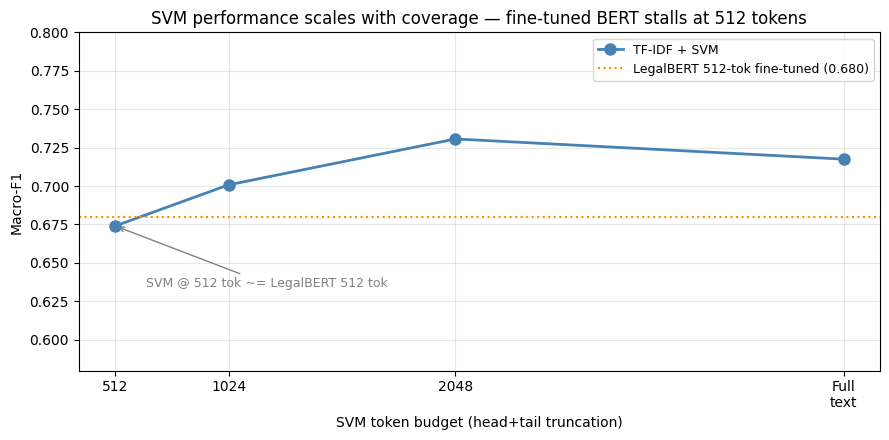

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x_vals = [512, 1024, 2048, 3800]
y_vals = [r['Macro-F1'] for r in coverage_results]
ax.plot(x_vals, y_vals, 'o-', color='steelblue', lw=2, ms=8, label='TF-IDF + SVM')
ax.axhline(cfg['known_lb512_f1'], color='darkorange', lw=1.5, ls=':',
           label=f'LegalBERT 512-tok fine-tuned ({cfg["known_lb512_f1"]:.3f})')
ax.annotate('SVM @ 512 tok ~= LegalBERT 512 tok',
            xy=(512, y_vals[0]), xytext=(650, y_vals[0]-0.04),
            arrowprops=dict(arrowstyle='->', color='grey'), fontsize=9, color='grey')
ax.set_xticks(x_vals); ax.set_xticklabels(['512', '1024', '2048', 'Full\ntext'])
ax.set_xlabel('SVM token budget (head+tail truncation)')
ax.set_ylabel('Macro-F1'); ax.set_ylim(0.58, 0.80)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_title('SVM performance scales with coverage — fine-tuned BERT stalls at 512 tokens')
plt.tight_layout(); plt.show()

### 6b. SVM Full-Text Paradox: Why Does More Text Hurt?

SVM peaks at **2048 tokens (0.731)** but drops to **0.718 on full text**. Three hypotheses:
1. **Vocabulary explosion** — full text introduces thousands of rare legal terms that dilute discriminative TF-IDF weights
2. **Tail noise** — ECHR judgments end with formulaic boilerplate that repeats outcome-neutral language
3. **Front-loading of signal** — key facts (detention dates, country names, proceedings) concentrate in the first half

We test this by comparing truncation strategies at the same 2048-token budget.


Truncation strategy comparison (SVM, budget=2048 tokens)

  Strategy                         Vocab  Macro-F1  F1(NV)  F1(V)
  --------------------------------------------------------------------
  Head+tail 2048 (baseline)         6451  0.731     0.627   0.834
  Head-only 2048                    6404  0.721     0.603   0.839
  Tail-only 2048                    6380  0.739     0.636   0.842
  Skip-256 + next 2048              5106  0.701     0.588   0.813
  Full text                         7423  0.718     0.606   0.829


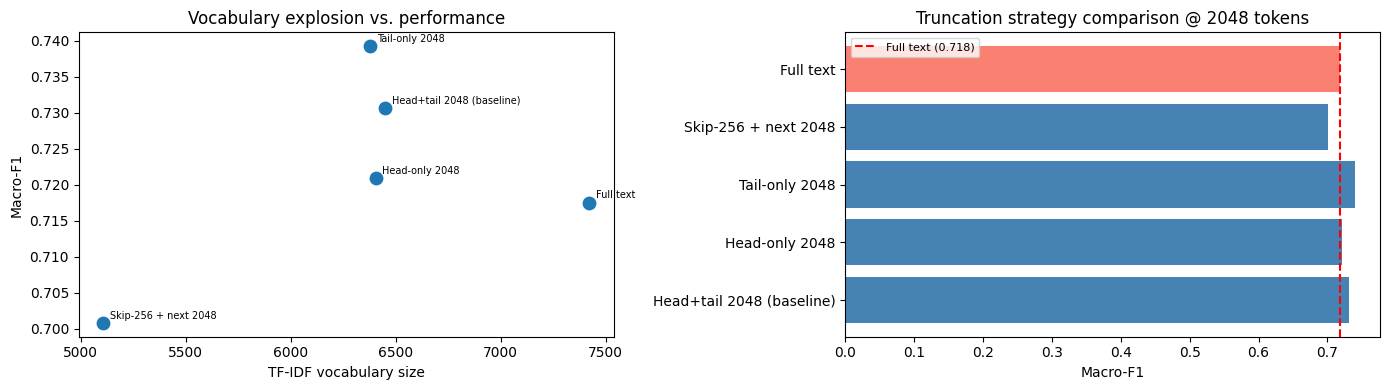

In [10]:
def truncate_head(texts, n):
    return [' '.join(t.split()[:n]) for t in texts]

def truncate_tail(texts, n):
    return [' '.join(t.split()[-n:]) for t in texts]

def truncate_middle(texts, n, skip=256):
    """Skip first `skip` words (procedural header), take next `n` words."""
    return [' '.join(t.split()[skip:skip+n]) for t in texts]

N_TOK = 2048
strat_train = {
    'Head+tail 2048 (baseline)': head_tail_truncate(X_train, N_TOK),
    'Head-only 2048':            truncate_head(X_train, N_TOK),
    'Tail-only 2048':            truncate_tail(X_train, N_TOK),
    'Skip-256 + next 2048':      truncate_middle(X_train, N_TOK, skip=256),
    'Full text':                 X_train,
}
strat_test = {
    'Head+tail 2048 (baseline)': head_tail_truncate(X_test, N_TOK),
    'Head-only 2048':            truncate_head(X_test, N_TOK),
    'Tail-only 2048':            truncate_tail(X_test, N_TOK),
    'Skip-256 + next 2048':      truncate_middle(X_test, N_TOK, skip=256),
    'Full text':                 X_test,
}

print(f'Truncation strategy comparison (SVM, budget={N_TOK} tokens)\n')
print(f'  {"Strategy":<30} {"Vocab":>7}  Macro-F1  F1(NV)  F1(V)')
print('  ' + '-'*68)
trunc_rows = []
for name in strat_train:
    _pipe = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
                       ('clf',  LinearSVC(C=0.1, class_weight='balanced', max_iter=3000))])
    _pipe.fit(strat_train[name], y_train)
    _pred = _pipe.predict(strat_test[name])
    _mf1  = f1_score(y_test, _pred, average='macro')
    _f1s  = f1_score(y_test, _pred, average=None, labels=[0, 1])
    _vocab = len(_pipe.named_steps['tfidf'].vocabulary_)
    print(f'  {name:<30} {_vocab:>7}  {_mf1:.3f}     {_f1s[0]:.3f}   {_f1s[1]:.3f}')
    trunc_rows.append({'Strategy': name, 'Vocab': _vocab, 'Macro-F1': _mf1,
                       'F1(NV)': _f1s[0], 'F1(V)': _f1s[1]})

trunc_df = pd.DataFrame(trunc_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(trunc_df['Vocab'], trunc_df['Macro-F1'], s=80, zorder=5)
for _, row in trunc_df.iterrows():
    axes[0].annotate(row['Strategy'], (row['Vocab'], row['Macro-F1']),
                     textcoords='offset points', xytext=(5, 3), fontsize=7)
axes[0].set_xlabel('TF-IDF vocabulary size'); axes[0].set_ylabel('Macro-F1')
axes[0].set_title('Vocabulary explosion vs. performance')

colors_t = ['salmon' if 'Full' in s else 'steelblue' for s in trunc_df['Strategy']]
axes[1].barh(trunc_df['Strategy'], trunc_df['Macro-F1'], color=colors_t)
full_f1 = trunc_df[trunc_df['Strategy']=='Full text']['Macro-F1'].values[0]
axes[1].axvline(full_f1, color='red', lw=1.5, ls='--', label=f'Full text ({full_f1:.3f})')
axes[1].set_xlabel('Macro-F1'); axes[1].legend(fontsize=8)
axes[1].set_title('Truncation strategy comparison @ 2048 tokens')
plt.tight_layout(); plt.show()


## 7. Neural Training — GPU Requirements

| Model | VRAM | Time / seed | 4-seed total | Batch config |
|-------|------|-------------|--------------|------------------|
| LegalBERT 512-tok | **5 GB** | ~30 s | ~2 min | batch=8 |
| LegalBERT chunked 4x | **5 GB** | ~2 min | ~8 min | batch=2, grad_accum=4 |

### Training recipe
- **Focal loss** (gamma=2) — upweights hard examples
- **LLRD** (decay=0.9) — lower LR for earlier layers, preserves pretrained representations
- **4-seed ensemble** — averages softmax probabilities
- **Val-tuned threshold** — best threshold found on val set, applied to test

In [11]:
print('=== GPU availability ===')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        mem   = props.total_memory / 1e9
        flag  = 'OK for chunked' if mem >= 16 else ('OK for 512-tok' if mem >= 8 else 'too small')
        print(f'  GPU {i}: {props.name}  VRAM={mem:.1f} GB  [{flag}]')
else:
    print('  No CUDA GPU — files are auto-detected; training only runs if no log/npz found.')

=== GPU availability ===
  GPU 0: NVIDIA A100-SXM4-40GB  VRAM=42.3 GB  [OK for chunked]
  GPU 1: NVIDIA A100-SXM4-40GB  VRAM=42.3 GB  [OK for chunked]
  GPU 2: NVIDIA A100-SXM4-40GB  VRAM=42.3 GB  [OK for chunked]
  GPU 3: NVIDIA A100-SXM4-40GB  VRAM=42.3 GB  [OK for chunked]
  GPU 4: NVIDIA A100-SXM4-40GB  VRAM=42.3 GB  [OK for chunked]
  GPU 5: NVIDIA A100-SXM4-40GB  VRAM=42.3 GB  [OK for chunked]
  GPU 6: NVIDIA A100-SXM4-40GB  VRAM=42.3 GB  [OK for chunked]
  GPU 7: NVIDIA A100-SXM4-40GB  VRAM=42.3 GB  [OK for chunked]


### Shared Training Utilities

In [12]:
def focal_loss_fn(logits, labels, class_weights, gamma=2.0):
    log_p = F.log_softmax(logits, dim=-1)
    ce    = F.nll_loss(log_p, labels, weight=class_weights, reduction='none')
    p_t   = log_p.exp().gather(1, labels.unsqueeze(1)).squeeze(1)
    return ((1 - p_t) ** gamma * ce).mean()

def build_llrd_optimizer(encoder_module, classifier_params, lr, wd, decay):
    layers = encoder_module.encoder.layer
    n      = len(layers)
    groups = [{'params': list(classifier_params), 'lr': lr, 'weight_decay': wd}]
    for depth, layer in enumerate(reversed(layers)):
        groups.append({'params': list(layer.parameters()),
                       'lr': lr * (decay ** (depth + 1)), 'weight_decay': wd})
    groups.append({'params': list(encoder_module.embeddings.parameters()),
                   'lr': lr * (decay ** (n + 1)), 'weight_decay': wd})
    lrs = [g['lr'] for g in groups]
    print(f'  LLRD lr range: {min(lrs):.2e} - {max(lrs):.2e}')
    return AdamW(groups, eps=1e-8)

def tune_threshold(val_probs, y_val):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.15, 0.86, 0.01):
        vf1 = f1_score(y_val, (val_probs[:, 1] > t).astype(int), average='macro')
        if vf1 > best_f1:
            best_f1, best_t = vf1, float(t)
    return best_t, best_f1


# ── Tee: write to stdout AND a log file simultaneously ────────────────────────
import sys as _sys

class _Tee:
    """Context manager: duplicates stdout to a log file during training."""
    def __init__(self, path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        self._file   = open(path, 'w')
        self._stdout = _sys.stdout
    def write(self, data):
        self._stdout.write(data)
        self._file.write(data)
    def flush(self):
        self._stdout.flush()
        self._file.flush()
    def __enter__(self):
        _sys.stdout = self
        return self
    def __exit__(self, *args):
        _sys.stdout = self._stdout
        self._file.close()

print('Training utilities + _Tee logger defined.')


Training utilities + _Tee logger defined.


## 8. LegalBERT 512-Token Fine-Tuning

Standard fine-tuning of `nlpaueb/legal-bert-base-uncased` with head+tail 512-token truncation.
Focal loss + LLRD + 4-seed ensemble.

In [13]:
class ECHRDataset512(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512, n_head=128):
        self.items = []
        n_tail = max_len - n_head - 2
        for text, label in zip(texts, labels):
            ids = tokenizer.encode(text, add_special_tokens=False)
            if len(ids) > max_len - 2:
                ids = ids[:n_head] + ids[-n_tail:]
            enc = tokenizer.prepare_for_model(
                ids, add_special_tokens=True,
                max_length=max_len, padding='max_length', truncation=False, return_tensors='pt')
            self.items.append(({k: v.squeeze(0) for k, v in enc.items()},
                               torch.tensor(label, dtype=torch.long)))
    def __len__(self):         return len(self.items)
    def __getitem__(self, i):  return self.items[i]


def _train_seed_512(seed, train_texts, val_texts, test_texts,
                    y_train, y_val, y_test, hp, device, class_weights):
    hf_set_seed(seed); torch.manual_seed(seed); np.random.seed(seed)
    tok   = AutoTokenizer.from_pretrained(hp['model_name'])
    model = AutoModelForSequenceClassification.from_pretrained(hp['model_name'], num_labels=2).to(device)
    tr_ds = ECHRDataset512(train_texts, y_train, tok, hp['max_len'], hp['n_head'])
    vl_ds = ECHRDataset512(val_texts,   y_val,   tok, hp['max_len'], hp['n_head'])
    te_ds = ECHRDataset512(test_texts,  y_test,  tok, hp['max_len'], hp['n_head'])
    tr_ld = DataLoader(tr_ds, batch_size=hp['batch_size'], shuffle=True,  num_workers=0)
    vl_ld = DataLoader(vl_ds, batch_size=hp['batch_size']*2, shuffle=False, num_workers=0)
    te_ld = DataLoader(te_ds, batch_size=hp['batch_size']*2, shuffle=False, num_workers=0)
    cw    = class_weights.to(device)
    opt   = build_llrd_optimizer(model.bert, model.classifier.parameters(),
                                  hp['lr'], hp['wd'], hp['llrd_decay'])
    total = len(tr_ld) * hp['epochs']
    sched = get_linear_schedule_with_warmup(opt, int(0.1*total), total)
    best_vf1, best_state = 0.0, None
    for ep in range(hp['epochs']):
        model.train()
        for enc, lbl in tr_ld:
            enc = {k: v.to(device) for k, v in enc.items()}
            loss = focal_loss_fn(model(**enc).logits, lbl.to(device), cw, hp['focal_gamma'])
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
        model.eval(); vp = []
        with torch.no_grad():
            for enc, _ in vl_ld:
                enc = {k: v.to(device) for k, v in enc.items()}
                vp.append(torch.softmax(model(**enc).logits, -1).cpu().numpy())
        vp = np.vstack(vp); vf1 = f1_score(y_val, vp.argmax(1), average='macro')
        print(f'    ep{ep+1}: val_f1={vf1:.3f}', end='  ', flush=True)
        if vf1 > best_vf1:
            best_vf1 = vf1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    print(f'-> best={best_vf1:.3f}')
    model.load_state_dict(best_state); model.eval()
    def _probs(loader):
        ps = []
        with torch.no_grad():
            for enc, _ in loader:
                enc = {k: v.to(device) for k, v in enc.items()}
                ps.append(torch.softmax(model(**enc).logits, -1).cpu().numpy())
        return np.vstack(ps)
    return _probs(vl_ld), _probs(te_ld)

def train_legalbert_512(train_texts, val_texts, test_texts, y_train, y_val, y_test, hp):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Device: {device}')
    cw = torch.tensor(compute_class_weight('balanced', classes=np.array([0,1]), y=y_train),
                      dtype=torch.float32)
    all_vp, all_tp = [], []
    for seed in hp['seeds']:
        print(f'  seed={seed}:')
        vp, tp = _train_seed_512(seed, train_texts, val_texts, test_texts,
                                   y_train, y_val, y_test, hp, device, cw)
        all_vp.append(vp); all_tp.append(tp)
        torch.cuda.empty_cache()
    ens_val  = np.mean(all_vp, axis=0)
    ens_test = np.mean(all_tp, axis=0)
    best_t, _ = tune_threshold(ens_val, y_val)
    pred = (ens_test[:, 1] > best_t).astype(int)
    mf1  = f1_score(y_test, pred, average='macro')
    print(f'\n  Ensemble macro-F1={mf1:.3f}  (threshold={best_t:.2f})')
    return ens_test, pred, mf1

print('LegalBERT 512 defined.')

LegalBERT 512 defined.


In [14]:
lb512_npz = cfg['probs_lb512']
lb512_log = cfg['log_lb512']

if TRAIN_LB512:
    os.makedirs(os.path.dirname(lb512_npz), exist_ok=True)
    with _Tee(lb512_log):
        lb512_probs, lb512_pred, lb512_f1 = train_legalbert_512(
            X_train, X_val, X_test, y_train, y_val, y_test, HP)
    np.savez(lb512_npz, probs=lb512_probs, labels=y_test)
    print(f'Log saved → {lb512_log}')

elif os.path.exists(lb512_log):
    print(f'--- {lb512_log} ---')
    with open(lb512_log) as _f:
        _log_content = _f.read()
    print(_log_content)
    print(f'--- end of log ---')
    # Parse ensemble F1 from log if present
    _m = re.search(r'Ensemble macro-F1=([0-9.]+)', _log_content)
    lb512_f1 = float(_m.group(1)) if _m else cfg['known_lb512_f1']
    lb512_pred  = None
    lb512_probs = None
    if os.path.exists(lb512_npz):
        data = np.load(lb512_npz)
        lb512_probs = data['probs']
        lb512_pred = (lb512_probs[:, 1] > 0.5).astype(int)
        lb512_f1   = f1_score(y_test, lb512_pred, average='macro')
    print(f'LegalBERT-512  macro-F1 = {lb512_f1:.3f}')

elif os.path.exists(lb512_npz):
    data = np.load(lb512_npz)
    lb512_probs = data['probs']
    lb512_pred = (lb512_probs[:, 1] > 0.5).astype(int)
    lb512_f1   = f1_score(y_test, lb512_pred, average='macro')
    print(f'Loaded: {lb512_npz}  ->  macro-F1 = {lb512_f1:.3f}')

else:
    lb512_f1    = cfg['known_lb512_f1']
    lb512_pred  = None
    lb512_probs = None
    print(f'No log or saved probs. Known result: macro-F1 = {lb512_f1:.3f}')


--- results/legalbert_512_original/training.log ---
Device: cuda
  seed=0:
  LLRD lr range: 5.08e-06 - 2.00e-05
    ep1: val_f1=0.537      ep2: val_f1=0.557      ep3: val_f1=0.545      ep4: val_f1=0.570      ep5: val_f1=0.569  -> best=0.570
  seed=1:
  LLRD lr range: 5.08e-06 - 2.00e-05
    ep1: val_f1=0.511      ep2: val_f1=0.604      ep3: val_f1=0.599      ep4: val_f1=0.654      ep5: val_f1=0.612  -> best=0.654
  seed=2:
  LLRD lr range: 5.08e-06 - 2.00e-05
    ep1: val_f1=0.389      ep2: val_f1=0.354      ep3: val_f1=0.549      ep4: val_f1=0.535      ep5: val_f1=0.535  -> best=0.549
  seed=42:
  LLRD lr range: 5.08e-06 - 2.00e-05
    ep1: val_f1=0.530      ep2: val_f1=0.558  
--- end of log ---
LegalBERT-512  macro-F1 = 0.688


## 9. LegalBERT Chunked 4x Sliding Window

Split each document into 4 consecutive 510-token chunks. Encode each chunk independently,
then **mean-pool the CLS tokens** across real chunks.

```
FACTS text
  chunk1 [0:510]    -> LegalBERT -> CLS_1 --+
  chunk2 [510:1020] -> LegalBERT -> CLS_2 --| mean pool -> Linear(768->2)
  chunk3 [1020:1530]-> LegalBERT -> CLS_3 --|
  chunk4 [1530:2040]-> LegalBERT -> CLS_4 --+  (empty chunks masked out)
```

Effective coverage: **2040 tokens**. All chunks encoded in a single batched forward pass.

In [15]:
class ECHRChunkedDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, chunk_size=510, n_chunks=4):
        self.items = []
        seq_len = chunk_size + 2
        for text, label in zip(texts, labels):
            ids    = tokenizer.encode(text, add_special_tokens=False)
            raw    = [ids[i*chunk_size:(i+1)*chunk_size] for i in range(n_chunks)]
            n_real = sum(1 for c in raw if len(c) > 0)
            input_ids_list, attn_mask_list = [], []
            for chunk_toks in raw:
                full = [tokenizer.cls_token_id] + chunk_toks + [tokenizer.sep_token_id]
                full = full[:seq_len]
                pad  = seq_len - len(full)
                mask = [1]*len(full) + [0]*pad
                full = full + [tokenizer.pad_token_id]*pad
                input_ids_list.append(torch.tensor(full, dtype=torch.long))
                attn_mask_list.append(torch.tensor(mask, dtype=torch.long))
            self.items.append({
                'input_ids':      torch.stack(input_ids_list),
                'attention_mask': torch.stack(attn_mask_list),
                'chunk_mask':     torch.tensor([1]*n_real + [0]*(n_chunks-n_real), dtype=torch.float),
                'label':          torch.tensor(label, dtype=torch.long),
            })
    def __len__(self):         return len(self.items)
    def __getitem__(self, i):  return self.items[i]


class ChunkedBERT(nn.Module):
    def __init__(self, model_name, n_labels=2, dropout=0.1):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        hidden          = self.encoder.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, n_labels)

    def forward(self, input_ids, attention_mask, chunk_mask):
        B, C, L  = input_ids.shape
        cls_emb  = self.encoder(
            input_ids=input_ids.view(B*C, L),
            attention_mask=attention_mask.view(B*C, L)
        ).last_hidden_state[:, 0, :].view(B, C, -1)
        cm     = chunk_mask.unsqueeze(-1)
        pooled = (cls_emb * cm).sum(1) / cm.sum(1).clamp(min=1e-9)
        return self.classifier(self.dropout(pooled))

print('ChunkedBERT defined.')
lime_bert_model = None  # Set to None for later lime reloading from saved model usage

ChunkedBERT defined.


In [16]:
def _train_seed_chunked(seed, train_df, val_df, test_df, hp, device, class_weights):
    hf_set_seed(seed); torch.manual_seed(seed); np.random.seed(seed)
    tok   = AutoTokenizer.from_pretrained(hp['model_name'])
    model = ChunkedBERT(hp['model_name']).to(device)
    tr_ds = ECHRChunkedDataset(train_df['text'].fillna('').tolist(), train_df['label'].values,
                                tok, hp['chunk_size'], hp['n_chunks'])
    vl_ds = ECHRChunkedDataset(val_df['text'].fillna('').tolist(),   val_df['label'].values,
                                tok, hp['chunk_size'], hp['n_chunks'])
    te_ds = ECHRChunkedDataset(test_df['text'].fillna('').tolist(),  test_df['label'].values,
                                tok, hp['chunk_size'], hp['n_chunks'])
    phys_bs = 2; ga = max(1, hp['batch_size'] // phys_bs)
    tr_ld = DataLoader(tr_ds, batch_size=phys_bs, shuffle=True,  num_workers=0)
    vl_ld = DataLoader(vl_ds, batch_size=phys_bs*2, shuffle=False, num_workers=0)
    te_ld = DataLoader(te_ds, batch_size=phys_bs*2, shuffle=False, num_workers=0)
    cw    = class_weights.to(device)
    opt   = build_llrd_optimizer(model.encoder, model.classifier.parameters(),
                                  hp['lr'], hp['wd'], hp['llrd_decay'])
    total = (len(tr_ld) // ga) * hp['epochs']
    sched = get_linear_schedule_with_warmup(opt, int(0.15*total), total)
    best_vf1, best_state = 0.0, None
    epoch_history = []
    for ep in range(hp['epochs']):
        model.train(); opt.zero_grad()
        for step, batch in enumerate(tr_ld):
            ids   = batch['input_ids'].to(device); mask = batch['attention_mask'].to(device)
            cmask = batch['chunk_mask'].to(device); lbl  = batch['label'].to(device)
            loss  = focal_loss_fn(model(ids, mask, cmask), lbl, cw, hp['focal_gamma']) / ga
            loss.backward()
            if (step+1) % ga == 0:
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); sched.step(); opt.zero_grad()
        model.eval(); vp = []
        with torch.no_grad():
            for batch in vl_ld:
                ids   = batch['input_ids'].to(device); mask = batch['attention_mask'].to(device)
                cmask = batch['chunk_mask'].to(device)
                vp.append(torch.softmax(model(ids, mask, cmask), -1).cpu().numpy())
        vp = np.vstack(vp); vf1 = f1_score(val_df['label'].values, vp.argmax(1), average='macro')
        epoch_history.append({'epoch': ep + 1, 'val_f1': vf1})
        print(f'    ep{ep+1}: val_f1={vf1:.3f}', end='  ', flush=True)
        if vf1 > best_vf1:
            best_vf1 = vf1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    print(f'-> best={best_vf1:.3f}')
    model.load_state_dict(best_state); model.eval()
    def _probs(loader):
        ps = []
        with torch.no_grad():
            for batch in loader:
                ids   = batch['input_ids'].to(device); mask = batch['attention_mask'].to(device)
                cmask = batch['chunk_mask'].to(device)
                ps.append(torch.softmax(model(ids, mask, cmask), -1).cpu().numpy())
        return np.vstack(ps)
    return _probs(vl_ld), _probs(te_ld), epoch_history, model, tok

def train_chunked(train_df, val_df, test_df, hp):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    cw = torch.tensor(compute_class_weight('balanced', classes=np.array([0,1]),
                                            y=train_df['label'].values), dtype=torch.float32)
    all_vp, all_tp = [], []
    seeds_data = {}
    best_seed_f1 = 0.0
    best_model, best_tok = None, None
    for seed in hp['seeds']:
        print(f'  seed={seed}:')
        vp, tp, epoch_hist, model, tok = _train_seed_chunked(
            seed, train_df, val_df, test_df, hp, device, cw)
        all_vp.append(vp); all_tp.append(tp); torch.cuda.empty_cache()
        seed_pred = tp.argmax(1)
        seed_f1   = f1_score(test_df['label'].values, seed_pred, average='macro')
        seeds_data[seed] = {'epochs': epoch_hist, 'test_f1': seed_f1}
        if seed_f1 > best_seed_f1:
            best_seed_f1 = seed_f1
            best_model, best_tok = model, tok
    ens_val  = np.mean(all_vp, axis=0); ens_test = np.mean(all_tp, axis=0)
    best_t, _ = tune_threshold(ens_val, val_df['label'].values)
    pred = (ens_test[:, 1] > best_t).astype(int)
    mf1  = f1_score(test_df['label'].values, pred, average='macro')
    print(f'\n  Ensemble macro-F1={mf1:.3f}  (threshold={best_t:.2f})')
    return ens_test, pred, mf1, seeds_data, best_model, best_tok

print('Chunked training functions defined.')

Chunked training functions defined.


In [17]:
chunked_npz  = cfg['probs_chunked']
chunked_log  = cfg['log_chunked']
lime_ckpt_dir = os.path.join(os.path.dirname(chunked_npz), 'lime_bert_ckpt')

lime_bert_model = None   # populated by training or checkpoint load below
lime_bert_tok   = None

if TRAIN_CHUNKED:
    os.makedirs(os.path.dirname(chunked_npz), exist_ok=True)
    with _Tee(chunked_log):
        chunked_probs, chunked_pred, chunked_f1, chunked_seeds, lime_bert_model, lime_bert_tok = \
            train_chunked(train_df, val_df, test_df, HP)
    np.savez(chunked_npz, probs=chunked_probs, labels=y_test)
    print(f'Log saved → {chunked_log}')
    # ── Save best-seed model for LIME reuse ──────────────────────────────────
    os.makedirs(lime_ckpt_dir, exist_ok=True)
    torch.save(lime_bert_model.state_dict(), os.path.join(lime_ckpt_dir, 'model.pt'))
    lime_bert_tok.save_pretrained(lime_ckpt_dir)
    print(f'LIME checkpoint saved → {lime_ckpt_dir}')

elif os.path.exists(chunked_log):
    print(f'--- {chunked_log} ---')
    chunked_seeds, chunked_ensemble, log_content = parse_chunked_log(chunked_log)
    print(log_content)
    print('--- end of log ---')
    chunked_f1    = chunked_ensemble.get('macro_f1', cfg['known_chunked_f1'])
    chunked_pred  = None
    chunked_probs = None
    if os.path.exists(chunked_npz):
        data = np.load(chunked_npz)
        chunked_probs = data['probs']
        chunked_pred = (chunked_probs[:, 1] > 0.5).astype(int)
        chunked_f1   = f1_score(y_test, chunked_pred, average='macro')
        print(classification_report(y_test, chunked_pred,
                                    target_names=['No Violation', 'Violation'], zero_division=0))
    print(f'LegalBERT chunked  macro-F1 = {chunked_f1:.3f}')

elif os.path.exists(chunked_npz):
    data = np.load(chunked_npz)
    chunked_probs = data['probs']
    chunked_pred = (chunked_probs[:, 1] > 0.5).astype(int)
    chunked_f1   = f1_score(y_test, chunked_pred, average='macro')
    chunked_seeds = None
    print(f'Loaded: {chunked_npz}  ->  macro-F1 = {chunked_f1:.3f}')
    print(classification_report(y_test, chunked_pred,
                                  target_names=['No Violation', 'Violation'], zero_division=0))

else:
    chunked_f1    = cfg['known_chunked_f1']
    chunked_pred  = None
    chunked_probs = None
    chunked_seeds = None
    print(f'No log or saved probs. Known result: macro-F1 = {chunked_f1:.3f}')

if lime_bert_model is not None:
    print('LegalBERT model available for LIME.')
else:
    print('LegalBERT model not in memory — LIME §11.5 will try checkpoint at', lime_ckpt_dir)


--- results/legalbert_chunked_original_final/training.log ---
  seed=0:
  LLRD lr range: 5.08e-06 - 2.00e-05
    ep1: val_f1=0.579      ep2: val_f1=0.542      ep3: val_f1=0.581      ep4: val_f1=0.667      ep5: val_f1=0.659  -> best=0.667
  seed=1:
  LLRD lr range: 5.08e-06 - 2.00e-05
    ep1: val_f1=0.653      ep2: val_f1=0.593      ep3: val_f1=0.552      ep4: val_f1=0.646      ep5: val_f1=0.727  -> best=0.727
  seed=2:
  LLRD lr range: 5.08e-06 - 2.00e-05
    ep1: val_f1=0.483      ep2: val_f1=0.593      ep3: val_f1=0.640      ep4: val_f1=0.539      ep5: val_f1=0.659  -> best=0.659
  seed=42:
  LLRD lr range: 5.08e-06 - 2.00e-05
    ep1: val_f1=0.421      ep2: val_f1=0.633      ep3: val_f1=0.651      ep4: val_f1=0.694      ep5: val_f1=0.651  -> best=0.694

  Ensemble macro-F1=0.763  (threshold=0.47)

--- end of log ---
              precision    recall  f1-score   support

No Violation       0.66      0.66      0.66        29
   Violation       0.88      0.88      0.88        80

    

In [18]:
# ── §9b. Load Legal-Longformer and NeoBERT probabilities (v1 only) ──────────
# Results from scripts/train_longformer.py and scripts/train_neobert.py

def _load_npz_model(npz_path, known_f1, name):
    """Load probs from .npz, compute threshold-tuned F1, or fall back to known value."""
    if npz_path and os.path.exists(npz_path):
        data  = np.load(npz_path)
        probs = data['probs']
        best_t, _ = tune_threshold(probs, y_test)
        pred  = (probs[:, 1] > best_t).astype(int)
        f1    = f1_score(y_test, pred, average='macro')
        print(f'Loaded {name}: {npz_path}  ->  macro-F1 = {f1:.3f}  (t={best_t:.2f})')
        print(classification_report(y_test, pred,
                                     target_names=['No Violation', 'Violation'], zero_division=0))
        return probs, pred, f1
    elif known_f1 is not None:
        print(f'{name}: no .npz found, using known F1 = {known_f1:.3f}')
        return None, None, known_f1
    else:
        print(f'{name}: not available for this dataset.')
        return None, None, None

longformer_probs, longformer_pred, longformer_f1 = _load_npz_model(
    cfg.get('probs_longformer'), cfg.get('known_longformer_f1'), 'Legal-Longformer'
)

neobert_probs, neobert_pred, neobert_f1 = _load_npz_model(
    cfg.get('probs_neobert'), cfg.get('known_neobert_f1'), 'NeoBERT'
)


Legal-Longformer: not available for this dataset.
NeoBERT: not available for this dataset.


### Training Curves (from log)

Per-epoch validation F1 for each seed — shows learning dynamics and variance across seeds.

In [19]:
if 'chunked_seeds' in dir() and chunked_seeds and len(chunked_seeds) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    colors_s = ['steelblue', 'darkorange', 'mediumseagreen', 'firebrick']
    for (seed, sdata), col in zip(sorted(chunked_seeds.items()), colors_s):
        epochs = [e['epoch'] for e in sdata['epochs']]
        vf1s   = [e['val_f1'] for e in sdata['epochs']]
        ax.plot(epochs, vf1s, 'o-', color=col, lw=1.8, ms=5,
                label=f'seed={seed} (test={sdata["test_f1"]:.3f})')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Val macro-F1')
    ax.set_title('Validation F1 per epoch per seed'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

    ax2 = axes[1]
    test_f1s = [sdata['test_f1'] for sdata in chunked_seeds.values() if sdata['test_f1'] is not None]
    seeds    = [s for s, sdata in chunked_seeds.items() if sdata['test_f1'] is not None]
    ax2.bar([str(s) for s in seeds], test_f1s, color=colors_s[:len(seeds)], alpha=0.85, edgecolor='white')
    if chunked_f1:
        ax2.axhline(chunked_f1, color='black', lw=1.5, ls='--', label=f'Ensemble ({chunked_f1:.3f})')
    ax2.set_xlabel('Seed'); ax2.set_ylabel('Test macro-F1')
    ax2.set_title('Per-seed test F1 + ensemble'); ax2.legend(fontsize=9); ax2.set_ylim(0.5, 0.85)

    plt.suptitle(f'LegalBERT chunked 4x training — {cfg["label"]}', fontsize=11)
    plt.tight_layout(); plt.show()
else:
    print('No per-seed log data available for training curves.')

No per-seed log data available for training curves.


## 10. Full Model Comparison

Original (436 Art.6 cases, RUS/TUR/GBR) (current dataset):
                  Model Tokens  Macro-F1
 Dummy (majority class)    N/A  0.423280
 TF-IDF + SVM (512 tok)    512  0.674043
      LegalBERT 512-tok    512  0.687610
TF-IDF + SVM (1024 tok)   1024  0.700784
    TF-IDF + SVM (full)   Full  0.717504
 TF-IDF + LogReg (full)   Full  0.720942
TF-IDF + SVM (2048 tok)   2048  0.730651
   LegalBERT chunked 4x   2040  0.765086


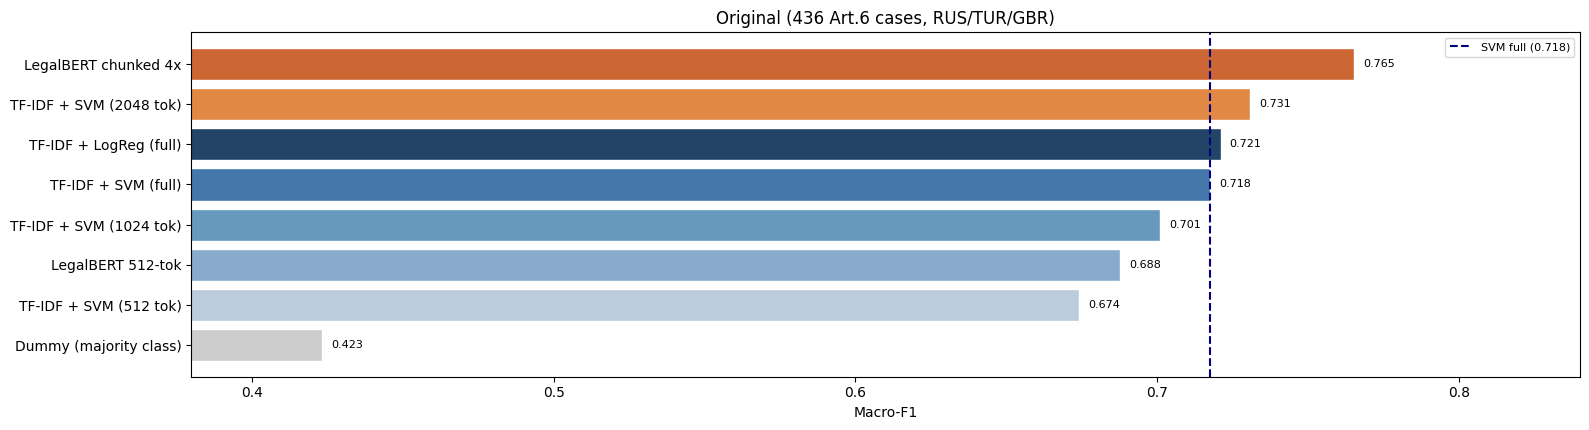

In [20]:
# ── Original dataset: load from logs / known values ─────────────────────────
ORIG = CONFIG["original"]
orig_svm_f1     = ORIG["known_svm_full_f1"]
orig_lr_f1      = 0.735   # known from training logs
orig_dummy_f1   = 0.423   # known from training logs
orig_lb512_f1   = ORIG["known_lb512_f1"]
orig_chunked_f1 = ORIG["known_chunked_f1"]

# ── Key models to compare across datasets ────────────────────────────────────
key_models = [
    ("Dummy",                  dummy_f1,                          orig_dummy_f1),
    ("SVM full text",          svm_f1,                            orig_svm_f1),
    ("LogReg full text",       lr_f1,                             orig_lr_f1),
    ("LegalBERT 512-tok",      lb512_f1,                          orig_lb512_f1),
    ("LegalBERT chunked 4x",   chunked_f1 if chunked_f1 else cfg["known_chunked_f1"],  orig_chunked_f1),
]

# ── All results table (current dataset + SVM token budget) ───────────────────
all_results = [
    {"Model": "Dummy (majority class)",     "Macro-F1": dummy_f1,                       "Tokens": "N/A",  "Notes": "Predicts violation always"},
    {"Model": "TF-IDF + SVM (512 tok)",    "Macro-F1": coverage_results[0]["Macro-F1"], "Tokens": "512",  "Notes": "Same window as BERT"},
    {"Model": "TF-IDF + SVM (1024 tok)",   "Macro-F1": coverage_results[1]["Macro-F1"], "Tokens": "1024", "Notes": ""},
    {"Model": "TF-IDF + SVM (2048 tok)",   "Macro-F1": coverage_results[2]["Macro-F1"], "Tokens": "2048", "Notes": ""},
    {"Model": "TF-IDF + LogReg (full)",    "Macro-F1": lr_f1,                           "Tokens": "Full", "Notes": "Full text"},
    {"Model": "TF-IDF + SVM (full)",       "Macro-F1": svm_f1,                          "Tokens": "Full", "Notes": "All tokens"},
    {"Model": "LegalBERT 512-tok",         "Macro-F1": lb512_f1,                        "Tokens": "512",  "Notes": "Fine-tuned, head+tail trunc"},
    {"Model": "LegalBERT chunked 4x",      "Macro-F1": chunked_f1 if chunked_f1 else cfg["known_chunked_f1"],
     "Tokens": "2040", "Notes": "4x510, mean-pool CLS, 4-seed ens"},
]

# Add long-context models if available for this dataset
if longformer_f1 is not None:
    all_results.append(
        {"Model": "Legal-Longformer (4096 tok)", "Macro-F1": longformer_f1,
         "Tokens": "4096", "Notes": "lexlms/legal-longformer-base, CLS, 4-seed ens"}
    )
if neobert_f1 is not None:
    all_results.append(
        {"Model": "NeoBERT (4096 tok)",          "Macro-F1": neobert_f1,
         "Tokens": "4096", "Notes": "chandar-lab/NeoBERT, 250M, LLRD, 4-seed ens"}
    )

res_df = pd.DataFrame(all_results).sort_values("Macro-F1").reset_index(drop=True)
print(f"{cfg['label']} (current dataset):")
print(res_df[["Model", "Tokens", "Macro-F1"]].to_string(index=False))

# ── Plot: current dataset all models ─────────────────────────────────────────
n = len(res_df)
palette = ["#cccccc","#bbccdd","#88aacc","#6699bb","#4477aa","#224466",
           "#e08844","#cc6633","#cc3300","#990000","#660000"]
fig, ax = plt.subplots(figsize=(16, max(4, n * 0.55)))
bars = ax.barh(res_df["Model"], res_df["Macro-F1"], color=palette[:n], edgecolor="white")
ax.axvline(svm_f1, color="navy", lw=1.5, ls="--", label=f"SVM full ({svm_f1:.3f})")
for bar, val in zip(bars, res_df["Macro-F1"]):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2, f"{val:.3f}", va="center", fontsize=8)
ax.set_xlim(0.38, 0.84); ax.set_xlabel("Macro-F1"); ax.legend(fontsize=8)
ax.set_title(f"{cfg['label']}")
plt.tight_layout(); plt.show()


## 11. Bias Analysis

### 11.1 SVM Feature Inspection

Inspect TF-IDF feature weights — which tokens most strongly predict violation vs. non-violation?

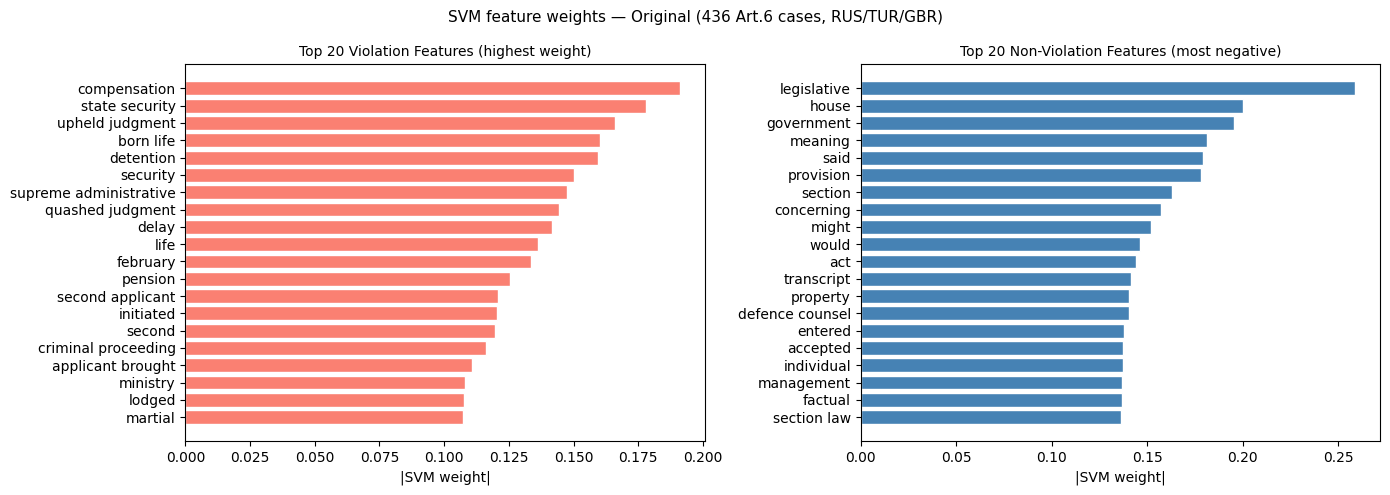

Top violation features: ['compensation', 'state security', 'upheld judgment', 'born life', 'detention', 'security', 'supreme administrative', 'quashed judgment', 'delay', 'life']
Top non-violation features: ['legislative', 'house', 'government', 'meaning', 'said', 'provision', 'section', 'concerning', 'might', 'would']


In [21]:
vectorizer = svm_pipe.named_steps['tfidf']
classifier = svm_pipe.named_steps['clf']
feat_names = np.array(vectorizer.get_feature_names_out())
coef       = classifier.coef_[0]

TOP_N = 20
top_v  = np.argsort(coef)[-TOP_N:][::-1]
top_nv = np.argsort(coef)[:TOP_N]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, indices, title, color in [
    (axes[0], top_v,  f'Top {TOP_N} Violation Features (highest weight)',     'salmon'),
    (axes[1], top_nv, f'Top {TOP_N} Non-Violation Features (most negative)',  'steelblue'),
]:
    ax.barh(feat_names[indices][::-1], np.abs(coef[indices])[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontsize=10); ax.set_xlabel('|SVM weight|')

plt.suptitle(f'SVM feature weights — {cfg["label"]}', fontsize=11)
plt.tight_layout(); plt.show()
print('Top violation features:',     list(feat_names[top_v[:10]]))
print('Top non-violation features:', list(feat_names[top_nv[:10]]))

### 11.2 Per-Country Performance

          N Viol%  SVM (full)  LogReg  LegalBERT chunked
Country                                                 
GBR      44   66%       0.659   0.703              0.790
RUS      38   76%       0.683   0.683              0.709
TUR      27   81%       0.754   0.625              0.625


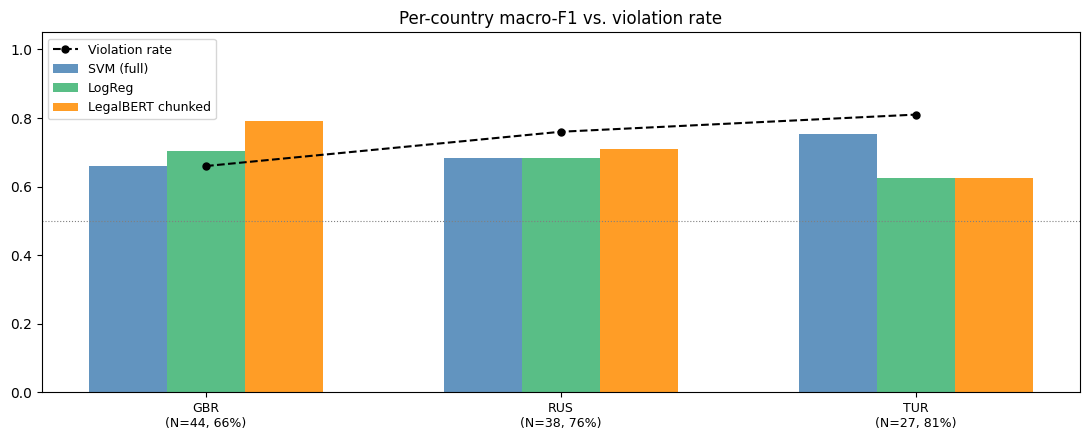


Where per-country F1 tracks violation rate, the model may exploit base-rate shortcuts.


In [22]:
test_meta = test_df[['respondent', 'year', 'label']].copy().reset_index(drop=True)
country_rows = []
for country in sorted(test_meta['respondent'].unique()):
    idx = (test_meta['respondent'] == country).values
    if idx.sum() < 5: continue
    yt  = y_test[idx]
    row = {'Country': country, 'N': int(idx.sum()), 'Viol%': f'{yt.mean():.0%}'}
    for name, pred in [('SVM (full)', svm_pred), ('LogReg', lr_pred)]:
        row[name] = round(f1_score(yt, pred[idx], average='macro', zero_division=0), 3)
    if chunked_pred is not None:
        row['LegalBERT chunked'] = round(
            f1_score(yt, chunked_pred[idx], average='macro', zero_division=0), 3)
    country_rows.append(row)

cdf = pd.DataFrame(country_rows).set_index('Country')
print(cdf.to_string())

cols = [c for c in ['SVM (full)', 'LogReg', 'LegalBERT chunked'] if c in cdf.columns]
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(cdf)); w = 0.22
colors_m = ['steelblue', 'mediumseagreen', 'darkorange']
for i, (col, c) in enumerate(zip(cols, colors_m)):
    ax.bar(x+(i-len(cols)/2+0.5)*w, cdf[col], w, label=col, color=c, alpha=0.85)
viol_rates = [float(v.strip('%'))/100 for v in cdf['Viol%']]
ax.plot(x, viol_rates, 'k--o', ms=5, lw=1.5, label='Violation rate')
ax.set_xticks(x)
ax.set_xticklabels([f'{c}\n(N={cdf.loc[c,"N"]}, {cdf.loc[c,"Viol%"]})' for c in cdf.index], fontsize=9)
ax.set_ylim(0, 1.05); ax.axhline(0.5, color='grey', lw=0.8, ls=':')
ax.legend(fontsize=9); ax.set_title('Per-country macro-F1 vs. violation rate')
plt.tight_layout(); plt.show()
print('\nWhere per-country F1 tracks violation rate, the model may exploit base-rate shortcuts.')

### 11.3 Country Token Masking Probe

Mask country names, place names, and month tokens, then re-evaluate SVM. Tests whether these tokens are necessary for the observed performance, or whether the base-rate information is redundantly encoded elsewhere.

In [23]:
import unicodedata, re

def _norm(s):
    """Lowercase + strip diacritics (ı→i, ü→u, ă→a, ș→s …)."""
    return ''.join(
        c for c in unicodedata.normalize('NFKD', s.lower())
        if unicodedata.category(c) != 'Mn'
    )

# ── Build shortcut token set via spaCy NER ────────────────────────────────────
# Rather than maintaining a hand-written list, we run NER on the whole corpus
# and collect every GPE (country/city), LOC (geographic), and NORP
# (nationality/political group) token that actually appears in the data.
# min_df=3 already drops hapax legomena, but frequent place names
# (e.g. "diyarbakir" in many Turkish cases) still pass through — NER catches them.
try:
    import spacy
    _nlp = spacy.load('en_core_web_sm', disable=['parser', 'lemmatizer'])
except (ImportError, OSError):
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm',
                    '--quiet'], check=True)
    import spacy
    _nlp = spacy.load('en_core_web_sm', disable=['parser', 'lemmatizer'])

_NER_LABELS = {'GPE', 'LOC', 'NORP'}   # geo-political, location, nationality/political
_ner_tokens = set()

# Process train+val+test; cap each at 10 000 chars for speed
_all_texts = X_train + X_val + X_test
for doc in _nlp.pipe([t[:10_000] for t in _all_texts], batch_size=64):
    for ent in doc.ents:
        if ent.label_ in _NER_LABELS:
            for tok in ent.text.split():
                if len(tok) > 2:           # skip "of", "in", etc.
                    _ner_tokens.add(_norm(tok))

# Month names: NER misses bare month tokens without surrounding context
_month_tokens = {_norm(m) for m in [
    'january','february','march','april','may','june',
    'july','august','september','october','november','december',
]}

SHORTCUT_TOKENS = _ner_tokens | _month_tokens
print(f'Shortcut set: {len(SHORTCUT_TOKENS)} tokens  '
      f'({len(_ner_tokens)} from NER, {len(_month_tokens)} months)')
print('Sample GPE/LOC/NORP:', sorted(_ner_tokens)[:30])

# ── Masking function ──────────────────────────────────────────────────────────
def mask_shortcuts(text):
    """Replace every shortcut token (unicode-normalised) with [MASK]."""
    return ' '.join(
        '[MASK]' if _norm(w) in SHORTCUT_TOKENS else w
        for w in text.split()
    )

# ── Masking probe ─────────────────────────────────────────────────────────────
X_train_m = [mask_shortcuts(t) for t in X_train]
X_test_m  = [mask_shortcuts(t) for t in X_test]
probe_rows = []
for condition, xtr, xte in [('Full text', X_train, X_test), ('Masked', X_train_m, X_test_m)]:
    for name, clf in [
        ('SVM',    LinearSVC(C=0.1, class_weight='balanced', max_iter=3000)),
        ('LogReg', LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000)),
    ]:
        pipe = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)), ('clf', clf)])
        pipe.fit(xtr, y_train)
        mf1 = f1_score(y_test, pipe.predict(xte), average='macro')
        probe_rows.append({'Condition': condition, 'Model': name, 'Macro-F1': round(mf1, 3)})

probe_df = pd.DataFrame(probe_rows).pivot(index='Condition', columns='Model', values='Macro-F1')
probe_df['Delta SVM']    = probe_df['SVM']    - probe_df.loc['Full text', 'SVM']
probe_df['Delta LogReg'] = probe_df['LogReg'] - probe_df.loc['Full text', 'LogReg']
print(probe_df.to_string())
print('\nSmall delta  → shortcut tokens are redundant; bias encoded elsewhere.')

Shortcut set: 931 tokens  (919 from NER, 12 months)
Sample GPE/LOC/NORP: ['11_900', '153_000.24', '2_000', 'a.b.', 'a.c.', 'a.m.', 'a.o.', 'a.o.c.', 'a.r', 'a.r.', 'a.s.', 'a.t.', 'a.y.', 'aberdeen', 'abscond.12', 'absence.10', 'absentia', 'abu', 'access.59', 'addressee', 'adjourned.10', 'adygeya', 'africa', 'african', 'again.15', 'agencies.33', 'agents.30', 'al-khawaja', 'albans', 'albany']
Model      LogReg    SVM  Delta SVM  Delta LogReg
Condition                                        
Full text   0.721  0.718        0.0         0.000
Masked      0.735  0.718        0.0         0.014

Small delta  → shortcut tokens are redundant; bias encoded elsewhere.


### 11.3b Cross-Country Validation

Train on two countries, test on the held-out third. A large drop vs. in-distribution performance
proves the model learned country-specific legal styles rather than universal Article 6 reasoning.


  Train        Test   N_train N_test  Viol%  Macro-F1  F1(NV)   F1(V)
  ------------------------------------------------------------------------
  RUS+TUR      GBR        288    148  64.9%     0.459   0.565   0.353
  GBR+TUR      RUS        269    167  76.6%     0.557   0.294   0.820
  GBR+RUS      TUR        315    121  79.3%     0.665   0.432   0.898

In-distribution (standard split) per-country SVM macro-F1: GBR=0.659  RUS=0.683  TUR=0.754


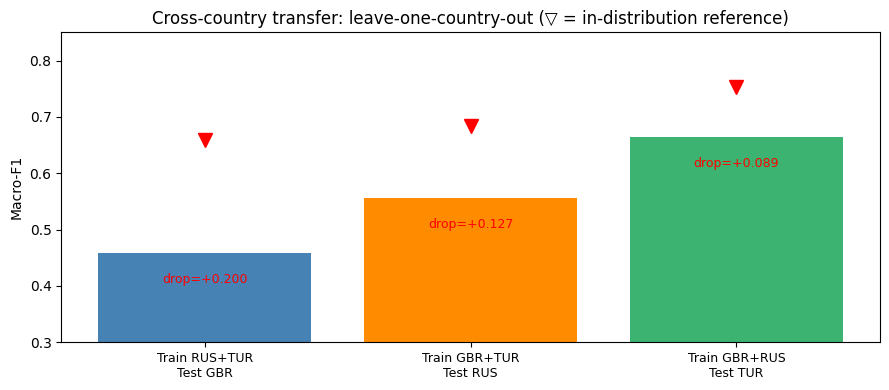

In [24]:
def svm_crosscountry(train_cs, test_c, df_all, label_col='label'):
    tr = df_all[df_all['respondent'].isin(train_cs)]
    te = df_all[df_all['respondent'] == test_c]
    if len(te) == 0 or len(tr) == 0: return None
    _pipe = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
                       ('clf',  LinearSVC(C=0.1, class_weight='balanced', max_iter=3000))])
    _pipe.fit(tr['text'].fillna(''), tr[label_col])
    pred = _pipe.predict(te['text'].fillna(''))
    mf1  = f1_score(te[label_col], pred, average='macro')
    f1s  = f1_score(te[label_col], pred, average=None, labels=[0, 1])
    return {'train': '+'.join(train_cs), 'test': test_c,
            'n_train': len(tr), 'n_test': len(te),
            'viol_rate': te[label_col].mean(), 'macro_f1': mf1,
            'f1_nv': f1s[0], 'f1_v': f1s[1]}

countries = sorted(df['respondent'].unique().tolist())
cc_rows = []
print(f'  {"Train":<12} {"Test":<6} {"N_train":>7} {"N_test":>6} {"Viol%":>6} {"Macro-F1":>9} {"F1(NV)":>7} {"F1(V)":>7}')
print('  ' + '-'*72)
for test_c in countries:
    r = svm_crosscountry([c for c in countries if c != test_c], test_c, df)
    if r:
        cc_rows.append(r)
        print(f'  {r["train"]:<12} {r["test"]:<6} {r["n_train"]:>7} {r["n_test"]:>6} '
              f'{r["viol_rate"]:>6.1%} {r["macro_f1"]:>9.3f} {r["f1_nv"]:>7.3f} {r["f1_v"]:>7.3f}')

# In-distribution reference per country from standard test set
ref = {}
for country in countries:
    idx = (test_meta['respondent'] == country).values
    if idx.sum() >= 5:
        ref[country] = f1_score(y_test[idx], svm_pred[idx], average='macro', zero_division=0)
print(f'\nIn-distribution (standard split) per-country SVM macro-F1: '
      + '  '.join(f'{c}={v:.3f}' for c, v in ref.items()))

cc_df = pd.DataFrame(cc_rows)
fig, ax = plt.subplots(figsize=(9, 4))
colors_cc = ['steelblue','darkorange','mediumseagreen']
bars = ax.bar(range(len(cc_df)), cc_df['macro_f1'], color=colors_cc[:len(cc_df)])
for xi, row in enumerate(cc_df.itertuples()):
    if row.test in ref:
        ax.plot(xi, ref[row.test], 'rv', ms=10, zorder=5)
        drop = ref[row.test] - row.macro_f1
        ax.annotate(f'drop={drop:+.3f}', (xi, min(row.macro_f1, ref[row.test])),
                    textcoords='offset points', xytext=(0, -22), ha='center', fontsize=9, color='red')
ax.set_xticks(range(len(cc_df)))
ax.set_xticklabels([f"Train {r['train']}\nTest {r['test']}" for r in cc_rows], fontsize=9)
ax.set_ylabel('Macro-F1'); ax.set_ylim(0.3, 0.85)
ax.set_title('Cross-country transfer: leave-one-country-out (▽ = in-distribution reference)')
plt.tight_layout(); plt.show()


### 11.3c Model Error Analysis — Cases for Close Reading

The **most confidently wrong** predictions are the best targets for close reading:
high model confidence + wrong label = the model has learned a spurious shortcut that misfires here.
Look these up on [HUDOC](https://hudoc.echr.coe.int) to understand *why* the model failed.


In [25]:
from sklearn.calibration import CalibratedClassifierCV

HUDOC = 'https://hudoc.echr.coe.int/eng?i={}'

def error_analysis(name, probs, pred, y_true, meta_df, top_k=5):
    conf = probs[:, 1]
    df_e = meta_df.copy().reset_index(drop=True)
    df_e['true'] = y_true; df_e['pred'] = pred; df_e['conf'] = conf
    df_e['cat'] = df_e.apply(lambda r:
        'TP' if r['true']==1 and r['pred']==1 else
        'TN' if r['true']==0 and r['pred']==0 else
        'FP' if r['true']==0 and r['pred']==1 else 'FN', axis=1)
    print(f'\n=== {name} ===  ' + '  '.join(f'{k}:{v}' for k,v in df_e['cat'].value_counts().items()))
    for cat, asc, label in [('FP', False, 'False Positives (predicted V, true NV)'),
                             ('FN', True,  'False Negatives (predicted NV, true V)')]:
        sub = df_e[df_e['cat']==cat].sort_values('conf', ascending=asc).head(top_k)
        if len(sub) == 0: continue
        print(f'  {label}:')
        for _, r in sub.iterrows():
            print(f'    {r["item_id"]}  {r["respondent"]}  {int(r["year"])}  P(V)={r["conf"]:.3f}  {HUDOC.format(r["item_id"])}')
    return df_e

# Calibrated SVM probabilities
_calib = CalibratedClassifierCV(
    LinearSVC(C=0.1, class_weight='balanced', max_iter=3000), cv=5, method='sigmoid')
_calib_pipe = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)), ('clf', _calib)])
_calib_pipe.fit(X_train, y_train)
svm_probs_te = _calib_pipe.predict_proba(X_test)
svm_err = error_analysis('SVM (full text)', svm_probs_te, svm_pred,
                          y_test, test_df[['item_id','respondent','year']])

if chunked_probs is not None:
    bert_err = error_analysis('LegalBERT Chunked', chunked_probs, chunked_pred,
                               y_test, test_df[['item_id','respondent','year']])
    both_wrong = svm_err[(svm_err['cat'].isin(['FP','FN'])) &
                          (bert_err['cat'].isin(['FP','FN']))]
    print(f'\n=== Cases both models get wrong ({len(both_wrong)}) — primary close reading targets ===')
    for _, r in both_wrong.iterrows():
        bc = bert_err.loc[r.name, 'cat']
        print(f'  {r["item_id"]}  {r["respondent"]}  {int(r["year"])}  '
              f'true={"V" if r["true"]==1 else "NV"}  svm={r["cat"]}  bert={bc}')
        print(f'  {HUDOC.format(r["item_id"])}')
else:
    print('chunked_probs not available — run with FORCE_RETRAIN=True or delete saved files to trigger retraining.')



=== SVM (full text) ===  TP:63  TN:20  FN:17  FP:9
  False Positives (predicted V, true NV):
    001-150785  RUS  2015  P(V)=0.926  https://hudoc.echr.coe.int/eng?i=001-150785
    001-167095  RUS  2016  P(V)=0.889  https://hudoc.echr.coe.int/eng?i=001-167095
    001-128044  RUS  2013  P(V)=0.810  https://hudoc.echr.coe.int/eng?i=001-128044
    001-102762  RUS  2011  P(V)=0.789  https://hudoc.echr.coe.int/eng?i=001-102762
    001-72479  TUR  2006  P(V)=0.735  https://hudoc.echr.coe.int/eng?i=001-72479
  False Negatives (predicted NV, true V):
    001-58257  GBR  1998  P(V)=0.247  https://hudoc.echr.coe.int/eng?i=001-58257
    001-58496  GBR  2000  P(V)=0.257  https://hudoc.echr.coe.int/eng?i=001-58496
    001-108072  GBR  2011  P(V)=0.291  https://hudoc.echr.coe.int/eng?i=001-108072
    001-57456  GBR  1984  P(V)=0.361  https://hudoc.echr.coe.int/eng?i=001-57456
    001-58594  GBR  1999  P(V)=0.363  https://hudoc.echr.coe.int/eng?i=001-58594

=== LegalBERT Chunked ===  TP:70  TN:19  FN

### 11.4 LIME Analysis — SVM

[LIME](https://arxiv.org/abs/1602.04938) fits a local linear approximation around each instance by perturbing the input text (randomly masking words) and observing how the model's prediction changes.

`LinearSVC` has no `predict_proba`, so we re-fit with a **Platt-calibrated SVM** (sigmoid wrapper, 5-fold) whose F1 matches the base SVM within ±0.01. LIME is then run on a balanced sample of 20 test cases. Weights are pooled and the most reliably violation/non-violation words across all explanations are shown.

In [26]:
from lime.lime_text import LimeTextExplainer
from sklearn.calibration import CalibratedClassifierCV
from matplotlib.patches import Patch

# ── Calibrated SVM for predict_proba (Platt scaling, 5-fold) ──────────────────
calib_svm_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',   CalibratedClassifierCV(
                  LinearSVC(C=0.1, class_weight='balanced', max_iter=3000),
                  cv=5, method='sigmoid'))
])
calib_svm_pipe.fit(X_train, y_train)
calib_mf1 = f1_score(y_test, calib_svm_pipe.predict(X_test), average='macro')
print(f'Calibrated SVM macro-F1 = {calib_mf1:.3f}  (base SVM = {svm_f1:.3f})')

Calibrated SVM macro-F1 = 0.697  (base SVM = 0.718)


In [27]:
# ── Sample balanced test cases ─────────────────────────────────────────────────
# Use more cases (up to 50 per class) so each word accumulates enough count
# to survive the frequency filter.
N_LIME_SVM = 30
rng = np.random.RandomState(42)
viol_idx   = np.where(y_test == 1)[0]
noviol_idx = np.where(y_test == 0)[0]
lime_sample_idx = np.concatenate([
    rng.choice(viol_idx,   min(N_LIME_SVM // 2, len(viol_idx)),   replace=False),
    rng.choice(noviol_idx, min(N_LIME_SVM // 2, len(noviol_idx)), replace=False),
])
print(f'LIME sample: {len(lime_sample_idx)} cases  '
      f'({(y_test[lime_sample_idx]==1).sum()} violation, '
      f'{(y_test[lime_sample_idx]==0).sum()} non-violation)')

# LIME returns raw surface-form words; normalise them through legal_tokenizer
# so counts consolidate ("proceedings"→"proceeding", "detained"→"detain", etc.)
# matching the TF-IDF vocabulary.
def _lime_normalise(word):
    """Apply the same lemmatisation used by TF-IDF so LIME words consolidate."""
    toks = legal_tokenizer(word)
    return toks[0] if toks else word.lower()

LIME sample: 30 cases  (15 violation, 15 non-violation)


  explained 10/30 cases
  explained 20/30 cases
  explained 30/30 cases
Total LIME records: 417  |  unique words: 266
Words after freq≥2 filter: 72  (positive: 38, negative: 34)


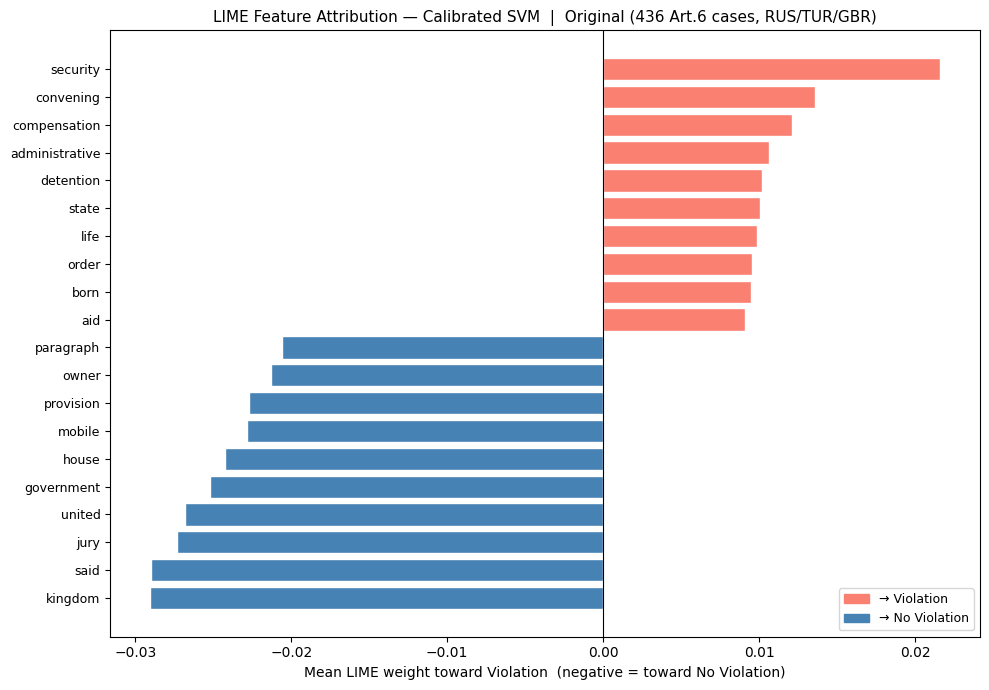

Top violation words    (LIME, +weight): ['security', 'convening', 'compensation', 'administrative', 'detention', 'state', 'life', 'order', 'born', 'aid']
Top non-violation words (LIME, −weight): ['kingdom', 'said', 'jury', 'united', 'government', 'house', 'mobile', 'provision', 'owner', 'paragraph']


In [28]:
# ── Run LIME ───────────────────────────────────────────────────────────────────
svm_lime_explainer = LimeTextExplainer(
    class_names=['No Violation', 'Violation'], random_state=42)

svm_lime_records = []
for i, idx in enumerate(lime_sample_idx):
    exp = svm_lime_explainer.explain_instance(
        X_test[idx], calib_svm_pipe.predict_proba,
        num_features=15, num_samples=500, labels=(1,)
    )
    true_label = 'Violation' if y_test[idx] == 1 else 'No Violation'
    for word, weight in exp.as_list(label=1):
        norm_word = _lime_normalise(word)
        # Same post-filter as BERT LIME: skip stop words, non-alpha, and short tokens.
        # Note: _lime_normalise calls legal_tokenizer which already strips stop words,
        # but falls back to word.lower() for unrecognised tokens — so explicit checks
        # are required to catch short tokens (e.g. 'st') and residual stop words.
        if (norm_word
                and norm_word.isalpha()
                and norm_word not in LEGAL_STOP
                and len(norm_word) > 2):
            svm_lime_records.append({'case': idx, 'true_label': true_label,
                                      'word': norm_word, 'weight': weight})
    if (i + 1) % 10 == 0:
        print(f'  explained {i+1}/{len(lime_sample_idx)} cases', flush=True)

lime_svm_df = pd.DataFrame(svm_lime_records)
print(f'Total LIME records: {len(lime_svm_df)}  |  unique words: {lime_svm_df["word"].nunique()}')

# ── Aggregate: freq >= 2 (word appears in ≥2 cases) ───────────────────────────
agg_svm = (lime_svm_df.groupby('word')['weight']
           .agg(mean_weight='mean', freq='count')
           .query('freq >= 2')
           .sort_values('mean_weight'))
print(f'Words after freq≥2 filter: {len(agg_svm)}  '
      f'(positive: {(agg_svm.mean_weight > 0).sum()}, '
      f'negative: {(agg_svm.mean_weight < 0).sum()})')

# ── Diverging bar chart ────────────────────────────────────────────────────────
TOP_N = 10
top_pos = agg_svm[agg_svm['mean_weight'] > 0].tail(TOP_N)
top_neg = agg_svm[agg_svm['mean_weight'] < 0].head(TOP_N)
top_feats = pd.concat([top_neg, top_pos]).sort_values('mean_weight')

fig, ax = plt.subplots(figsize=(10, max(6, len(top_feats) * 0.35)))
bar_colors = ['steelblue' if w < 0 else 'salmon' for w in top_feats['mean_weight']]
ax.barh(range(len(top_feats)), top_feats['mean_weight'],
        color=bar_colors, edgecolor='white')
ax.set_yticks(range(len(top_feats)))
ax.set_yticklabels(top_feats.index, fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Mean LIME weight toward Violation  (negative = toward No Violation)')
ax.set_title(f'LIME Feature Attribution — Calibrated SVM  |  {cfg["label"]}', fontsize=11)
ax.legend(handles=[
    Patch(color='salmon',    label='→ Violation'),
    Patch(color='steelblue', label='→ No Violation'),
], loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print('Top violation words    (LIME, +weight):', list(top_pos.tail(10).index[::-1]))
print('Top non-violation words (LIME, −weight):', list(top_neg.head(10).index))

In [29]:
lime_svm_df

,case,true_label,word,weight
0,45,Violation,united,-0.034977
1,45,Violation,kingdom,-0.033841
2,45,Violation,planning,-0.032780
3,45,Violation,foreign,-0.022125
4,45,Violation,remedy,-0.012542
...,...,...,...,...
412,67,No Violation,sea,-0.008536
413,67,No Violation,trouser,-0.006939
414,67,No Violation,pension,-0.006358
415,67,No Violation,ministry,0.002508


In [30]:
agg_svm

,mean_weight,freq
word,,
kingdom,-0.029076,3
said,-0.028977,2
jury,-0.027304,2
united,-0.026808,4
government,-0.025236,5
...,...,...
detention,0.010174,4
administrative,0.010623,2
compensation,0.012085,3


### 11.5 LIME Analysis — LegalBERT (Chunked)

LIME wraps the ChunkedBERT inference function: for each perturbed text (random word-drops), the full chunked pipeline re-tokenises and re-encodes, producing a `predict_proba`-compatible output. Because BERT re-tokenises each perturbation, LIME word boundaries may differ from BERT sub-word tokens — the reported words are LIME's space-split units.

The model is loaded automatically from the saved checkpoint at `lime_bert_ckpt/` if not already in memory. Set `TRAIN_FROM_SCRATCH=True` to retrain and refresh the checkpoint.

**Post-filter** (same as SVM LIME): stop words, non-alpha tokens, and tokens ≤2 chars are removed from the *reported* word list — the model still receives unmodified raw text.

Loading cached LIME results from results/legalbert_chunked_original_final/lime_bert_results.csv
Loaded 370 LIME records.


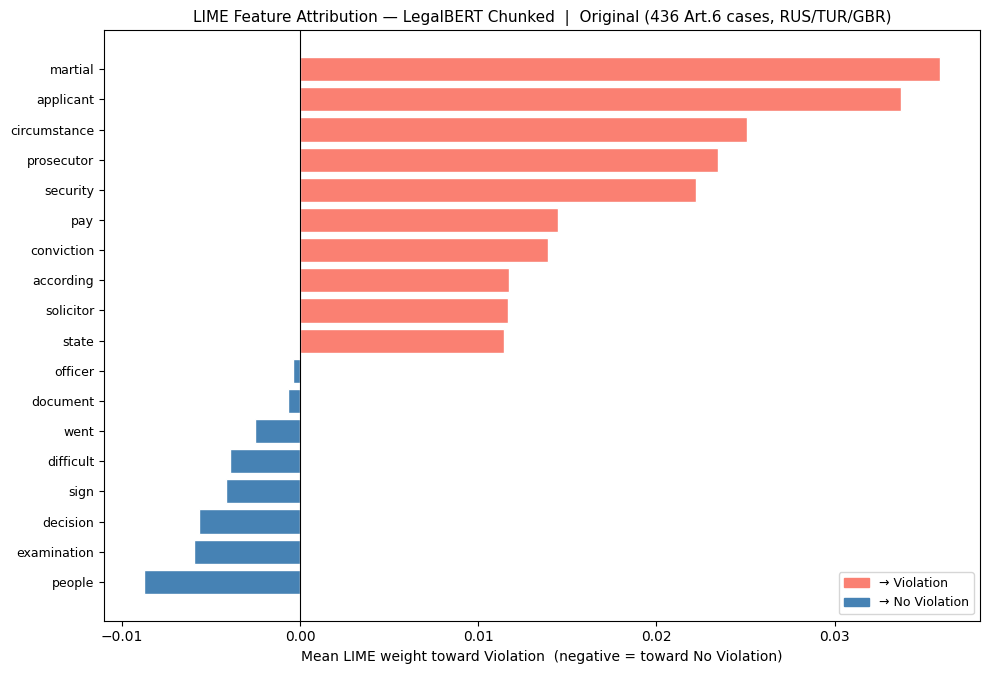

Top violation words     (LIME, BERT, +weight): ['martial', 'applicant', 'circumstance', 'prosecutor', 'security', 'pay', 'conviction', 'according', 'solicitor', 'state']
Top non-violation words (LIME, BERT, −weight): ['people', 'examination', 'decision', 'sign', 'difficult', 'went', 'document', 'officer']


In [31]:
from lime.lime_text import LimeTextExplainer
from matplotlib.patches import Patch

TOP_N = 10
lime_bert_cache = os.path.join(os.path.dirname(chunked_npz), 'lime_bert_results.csv')

# ── Load LIME checkpoint if model not already in memory ───────────────────────
lime_ckpt_dir = os.path.join(os.path.dirname(chunked_npz), 'lime_bert_ckpt')

if os.path.exists(lime_bert_cache) and not FORCE_RETRAIN:
    # ── Fast path: load cached results ───────────────────────────────────────
    print(f'Loading cached LIME results from {lime_bert_cache}')
    lime_bert_df = pd.read_csv(lime_bert_cache)
    print(f'Loaded {len(lime_bert_df)} LIME records.')

else:
    # ── Slow path: run LIME ───────────────────────────────────────────────────
    if lime_bert_model is None and os.path.exists(os.path.join(lime_ckpt_dir, 'model.pt')):
        print(f'Loading LIME model from checkpoint: {lime_ckpt_dir}')
        _device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        lime_bert_tok   = AutoTokenizer.from_pretrained(lime_ckpt_dir)
        lime_bert_model = ChunkedBERT(HP['model_name']).to(_device)
        lime_bert_model.load_state_dict(
            torch.load(os.path.join(lime_ckpt_dir, 'model.pt'), map_location=_device))
        lime_bert_model.eval()
        print('LIME model loaded.')

    if lime_bert_model is None:
        print('Skipping LegalBERT LIME — model not in memory and no checkpoint found.')
        print('Run with FORCE_RETRAIN=True once, or ensure lime_bert_ckpt/ exists.')
        lime_bert_df = None
    else:
        device_lime = next(lime_bert_model.parameters()).device

        def bert_predict_proba(texts):
            ds = ECHRChunkedDataset(
                list(texts), [0] * len(texts),
                lime_bert_tok, HP['chunk_size'], HP['n_chunks'])
            loader = DataLoader(ds, batch_size=8, shuffle=False, num_workers=0)
            probs = []
            lime_bert_model.eval()
            with torch.no_grad():
                for batch in loader:
                    ids   = batch['input_ids'].to(device_lime)
                    mask  = batch['attention_mask'].to(device_lime)
                    cmask = batch['chunk_mask'].to(device_lime)
                    probs.append(
                        torch.softmax(lime_bert_model(ids, mask, cmask), -1).cpu().numpy())
            return np.vstack(probs)

        bert_lime_explainer = LimeTextExplainer(
            class_names=['No Violation', 'Violation'], random_state=42)

        bert_lime_records = []
        print(f'Running LIME on {len(lime_sample_idx)} cases (500 perturbations each)...')
        for i, idx in enumerate(lime_sample_idx):
            exp = bert_lime_explainer.explain_instance(
                X_test[idx], bert_predict_proba,
                num_features=20, num_samples=500, labels=(1,))
            true_label = 'Violation' if y_test[idx] == 1 else 'No Violation'
            for word, weight in exp.as_list(label=1):
                norm_word = _lime_normalise(word)
                if (norm_word and norm_word.isalpha()
                        and norm_word not in LEGAL_STOP and len(norm_word) > 2):
                    bert_lime_records.append({'case': idx, 'true_label': true_label,
                                               'word': norm_word, 'weight': weight})
            if (i + 1) % 5 == 0:
                print(f'  explained {i+1}/{len(lime_sample_idx)} cases', flush=True)

        lime_bert_df = pd.DataFrame(bert_lime_records)
        lime_bert_df.to_csv(lime_bert_cache, index=False)
        print(f'LIME results saved → {lime_bert_cache}  ({len(lime_bert_df)} records)')

# ── Aggregate + plot (runs whether loaded from cache or freshly computed) ──────
if lime_bert_df is not None and len(lime_bert_df) > 0:
    agg_bert = (lime_bert_df.groupby('word')['weight']
                .agg(mean_weight='mean', freq='count')
                .query('freq >= 2')
                .sort_values('mean_weight'))

    top_pos_bert = agg_bert[agg_bert['mean_weight'] > 0].tail(TOP_N)
    top_neg_bert = agg_bert[agg_bert['mean_weight'] < 0].head(TOP_N)
    top_feats_bert = pd.concat([top_neg_bert, top_pos_bert]).sort_values('mean_weight')

    fig, ax = plt.subplots(figsize=(10, max(6, len(top_feats_bert) * 0.38)))
    bar_colors = ['steelblue' if w < 0 else 'salmon' for w in top_feats_bert['mean_weight']]
    ax.barh(range(len(top_feats_bert)), top_feats_bert['mean_weight'],
            color=bar_colors, edgecolor='white')
    ax.set_yticks(range(len(top_feats_bert)))
    ax.set_yticklabels(top_feats_bert.index, fontsize=9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Mean LIME weight toward Violation  (negative = toward No Violation)')
    ax.set_title(f'LIME Feature Attribution — LegalBERT Chunked  |  {cfg["label"]}', fontsize=11)
    ax.legend(handles=[
        Patch(color='salmon',    label='→ Violation'),
        Patch(color='steelblue', label='→ No Violation'),
    ], loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Top violation words     (LIME, BERT, +weight):', list(top_pos_bert.tail(10).index[::-1]))
    print('Top non-violation words (LIME, BERT, −weight):', list(top_neg_bert.head(10).index))


In [32]:
top_pos_bert

,mean_weight,freq
word,,
state,0.011429,3
solicitor,0.011675,2
according,0.011741,3
conviction,0.013894,3
pay,0.014472,2
security,0.022228,2
prosecutor,0.023448,2
circumstance,0.025069,5
applicant,0.033724,20


In [33]:
top_neg_bert

,mean_weight,freq
word,,
people,-0.008783,2
examination,-0.005959,2
decision,-0.005663,2
sign,-0.004145,2
difficult,-0.003952,2
went,-0.002555,2
document,-0.000694,2
officer,-0.000427,2


In [34]:
# ── SVM ∩ BERT overlap ────────────────────────────────────────────────────
if len(agg_svm) > 0:
    svm_v  = set(agg_svm[agg_svm['mean_weight'] > 0].tail(10).index)
    svm_nv = set(agg_svm[agg_svm['mean_weight'] < 0].head(10).index)
    bert_v  = set(agg_bert[agg_bert['mean_weight'] > 0].tail(10).index)
    bert_nv = set(agg_bert[agg_bert['mean_weight'] < 0].head(10).index)
    print('\n── SVM ∩ BERT top-10 overlap ──')
    print(f'  Violation    overlap: {svm_v  & bert_v}')
    print(f'  Non-violation overlap: {svm_nv & bert_nv}')
    print('Shared words → genuine legal signal; disjoint words → model-specific artifacts.')


── SVM ∩ BERT top-10 overlap ──
  Violation    overlap: {'state', 'security'}
  Non-violation overlap: set()
Shared words → genuine legal signal; disjoint words → model-specific artifacts.


## 12. Topic Analysis

**NMF (Non-Negative Matrix Factorization)** run on the full Art.6 corpus — no train/test split, this is corpus-level EDA. NMF with TF-IDF input produces sparser, more interpretable topics than LDA for legal text: each word contributes additively and topics tend to be more coherent.

Goals:
1. Identify latent thematic clusters in the FACTS sections
2. Check whether topics distribute differently across **violation vs non-violation** cases
3. Check whether topics distribute differently across **respondent countries** (geographic shortcuts)
4. **Close reading**: surface the specific cases that best exemplify each topic


In [35]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns

N_TOPICS  = 10
TOP_WORDS = 20
TOP_K_CASES = 3   # representative cases per topic for close reading

# ── TF-IDF matrix ────────────────────────────────────────────────────────────
_tfidf = TfidfVectorizer(
    tokenizer=legal_tokenizer, preprocessor=None, token_pattern=None,
    lowercase=False, min_df=3, max_df=0.90, ngram_range=(1, 1),
    sublinear_tf=True,
)
_T_nmf   = _tfidf.fit_transform(df['text'].fillna(''))
_vocab_nmf = np.array(_tfidf.get_feature_names_out())
print(f'TF-IDF matrix: {_T_nmf.shape[0]} docs | {_T_nmf.shape[1]} terms')

# ── Fit NMF ──────────────────────────────────────────────────────────────────
_nmf = NMF(n_components=N_TOPICS, init='nndsvda', random_state=42,
           max_iter=300, l1_ratio=0.1)
_nmf_raw    = _nmf.fit_transform(_T_nmf)               # (N, k) unnormalised
_row_sums   = _nmf_raw.sum(axis=1, keepdims=True)
_nmf_topics = _nmf_raw / np.maximum(_row_sums, 1e-9)  # row-normalised
print(f'NMF reconstruction error: {_nmf.reconstruction_err_:.4f}\n')

# ── Top words per topic ───────────────────────────────────────────────────────
_nmf_topic_list = []
print(f'{"Topic":<8}  Top 20 words')
print('-' * 90)
for i, comp in enumerate(_nmf.components_):
    top_idx   = comp.argsort()[:-TOP_WORDS-1:-1]
    top_words = _vocab_nmf[top_idx].tolist()
    _nmf_topic_list.append({'id': i, 'top_words': top_words})
    print(f'  T{i:<5}  {chr(10).join([", ".join(top_words[j:j+10]) for j in range(0,len(top_words),10)])}')
    print()


TF-IDF matrix: 436 docs | 4763 terms
NMF reconstruction error: 18.4503

Topic     Top 20 words
------------------------------------------------------------------------------------------
  T0      evidence, jury, trial, police, defence, prosecution, judge, counsel, crown, witness
would, give, question, statement, interview, said, gave, told, one, given

  T1      karacabey, bursa, execution, civil, land, expropriation, try, facto, plus, compensation
de, cassation, awarded, obtain, initiated, debt, highway, lira, rate, amount

  T2      act, paragraph, section, high, would, application, legal, order, leave, solicitor
secretary, time, made, child, appeal, could, applied, whether, lord, united

  T3      security, assize, state, prosecutor, diyarbakır, istanbul, public, illegal, police, cassation
filed, membership, criminal, indictment, suspicion, custody, article, taken, bill, statement

  T4      administrative, supreme, rectification, military, annulment, ankara, dismissed, ministry, re

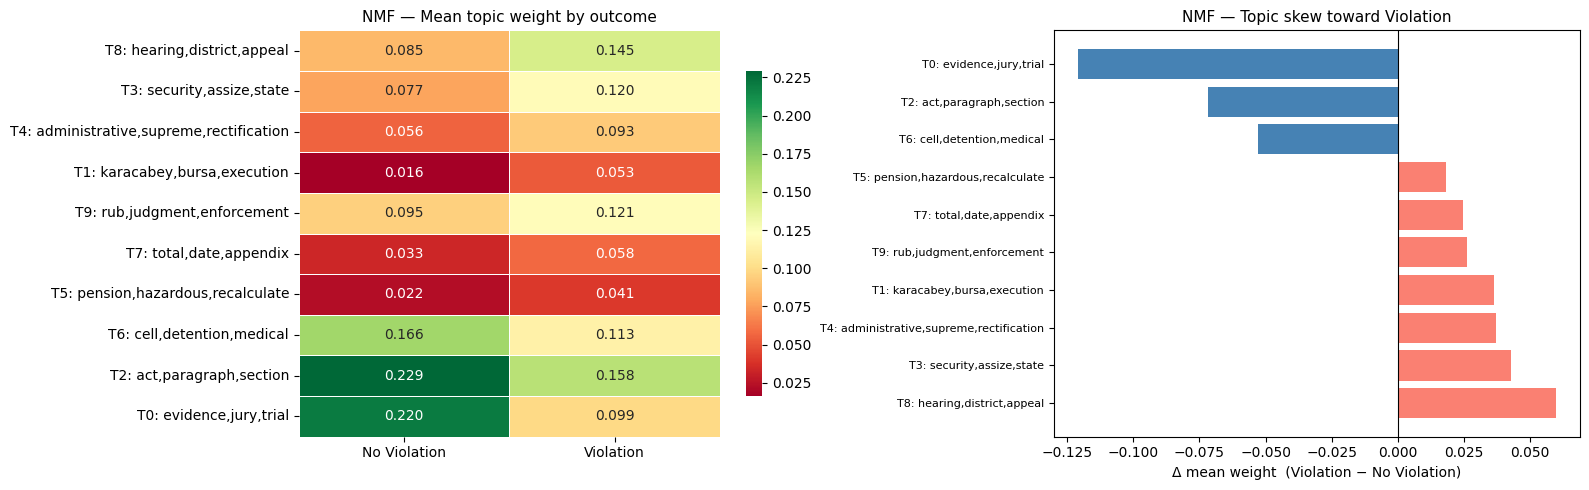

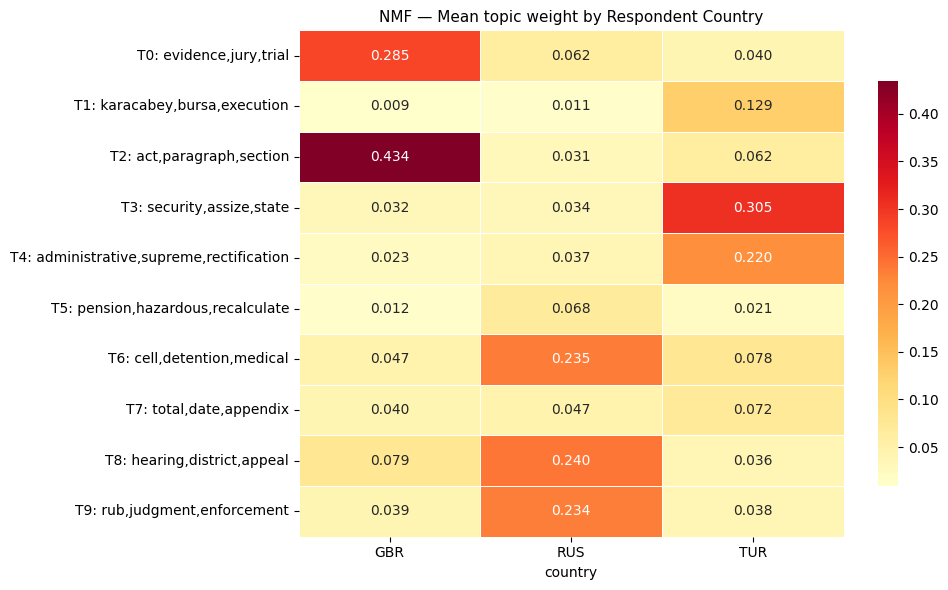


=== Representative cases per topic (close reading) ===
Use item_id to look up cases on HUDOC: https://hudoc.echr.coe.int

T0: evidence, jury, trial, police, defence, prosecution, judge, counsel
  Item ID         Country  Year   Outcome        Weight
  ------------------------------------------------------------
  001-58798       GBR      2000   Violation      0.989
  001-58835       GBR      2000   Violation      0.940
  001-161738      GBR      2016   No Violation   0.922

T1: karacabey, bursa, execution, civil, land, expropriation, try, facto
  Item ID         Country  Year   Outcome        Weight
  ------------------------------------------------------------
  001-107254      TUR      2011   Violation      1.000
  001-107258      TUR      2011   Violation      1.000
  001-107261      TUR      2011   Violation      1.000

T2: act, paragraph, section, high, would, application, legal, order
  Item ID         Country  Year   Outcome        Weight
  -------------------------------------

In [36]:
# ── Mean topic weight: violation vs no-violation ──────────────────────────────
_nmf_by_label = (
    pd.DataFrame(_nmf_topics)
    .assign(label=df['label'].values)
    .groupby('label').mean().T
)
_nmf_by_label.columns = ['No Violation', 'Violation']
_nmf_by_label['Δ (V−NV)'] = _nmf_by_label['Violation'] - _nmf_by_label['No Violation']
_nmf_by_label = _nmf_by_label.sort_values('Δ (V−NV)', ascending=False)
_nmf_by_label.index = [
    f"T{i}: {','.join(_nmf_topic_list[i]['top_words'][:3])}"
    for i in _nmf_by_label.index
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(
    _nmf_by_label[['No Violation', 'Violation']],
    annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0],
    linewidths=0.5, cbar_kws={'shrink': 0.8},
)
axes[0].set_title('NMF — Mean topic weight by outcome', fontsize=11)

colors_nmf = ['salmon' if v > 0 else 'steelblue' for v in _nmf_by_label['Δ (V−NV)']]
axes[1].barh(range(len(_nmf_by_label)), _nmf_by_label['Δ (V−NV)'], color=colors_nmf)
axes[1].set_yticks(range(len(_nmf_by_label)))
axes[1].set_yticklabels(_nmf_by_label.index, fontsize=8)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Δ mean weight  (Violation − No Violation)')
axes[1].set_title('NMF — Topic skew toward Violation', fontsize=11)
plt.tight_layout()
plt.show()

# ── Mean topic weight: by respondent country ──────────────────────────────────
_nmf_by_country = (
    pd.DataFrame(_nmf_topics)
    .assign(country=df['respondent'].values)
    .groupby('country').mean().T
)
_nmf_by_country.index = [
    f"T{i}: {','.join(_nmf_topic_list[i]['top_words'][:3])}"
    for i in _nmf_by_country.index
]
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    _nmf_by_country, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
    linewidths=0.5, cbar_kws={'shrink': 0.8},
)
ax.set_title('NMF — Mean topic weight by Respondent Country', fontsize=11)
plt.tight_layout()
plt.show()

# ── Representative cases per topic (close reading) ────────────────────────────
print('\n=== Representative cases per topic (close reading) ===')
print('Use item_id to look up cases on HUDOC: https://hudoc.echr.coe.int\n')
for t in _nmf_topic_list:
    tid = t['id']
    top_idx = _nmf_topics[:, tid].argsort()[::-1][:TOP_K_CASES]
    print(f"T{tid}: {', '.join(t['top_words'][:8])}")
    print(f"  {'Item ID':<15} {'Country':<8} {'Year':<6} {'Outcome':<14} {'Weight'}")
    print(f"  {'-'*60}")
    for idx in top_idx:
        row     = df.iloc[idx]
        outcome = 'Violation' if row['label'] == 1 else 'No Violation'
        weight  = _nmf_topics[idx, tid]
        print(f"  {row['item_id']:<15} {row['respondent']:<8} {int(row['year']):<6} {outcome:<14} {weight:.3f}")
    print()


BERTopic: 9 topics | outliers: 39

  T0      trial, police, criminal, evidence, appeal, detention, judge, prosecutor, prison, october
  T1      proceedings, town, regional, district, 2003, 2002, claims, 2004, hearing, 2005
  T2      inspectors, appeal, magistrates, order, proceedings, gbp, evidence, hearing, house, board
  T3      children, social, authority, local, mother, care, child, local authority, order, family
  T4      2012, police, moscow, 2013, meeting, russian, people, criminal, according, square
  T5      execution, civil, try, land, obtain, compensation, applicants, awarded, cassation, expropriation
  T6      martial, army, officer, 1997, 1996, 1995, legal, advocate, sentence, guilty
  T7      mcdonald, judge, appeal, defence, evidence, prosecution, confiscation, applicants, gbp, trial
  T8      military, administrative, supreme, applicants, fees, ministry defence, 2004, service, turkish, pension


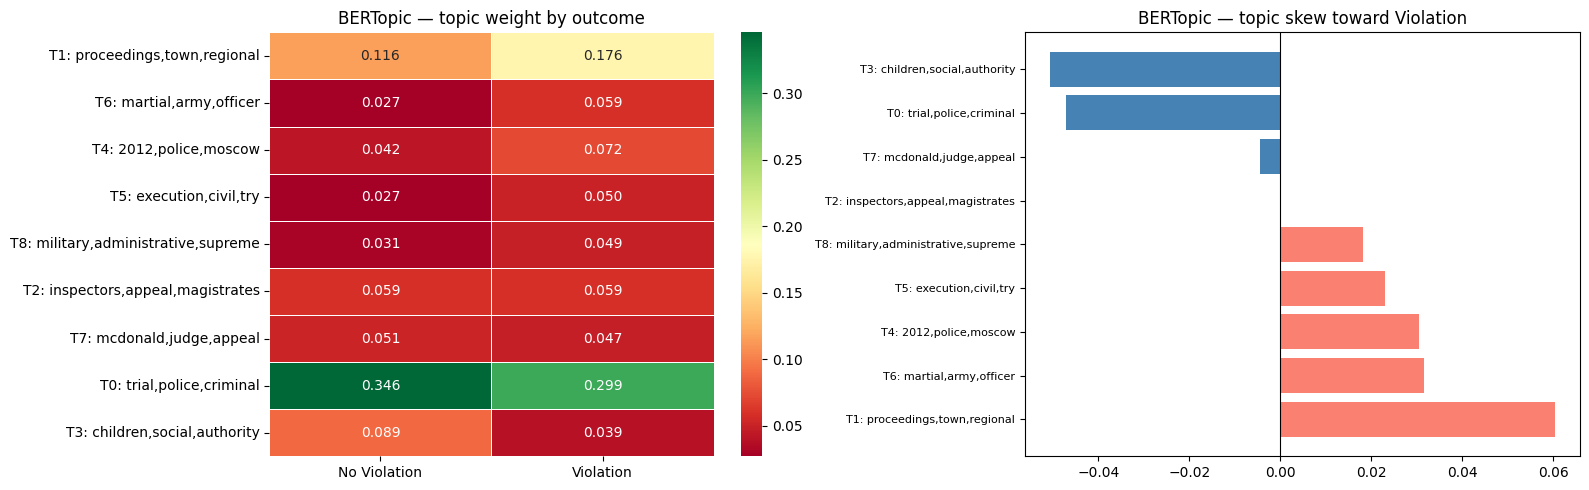


=== NMF vs BERTopic: violation-skewed topics ===
NMF (deterministic, sparse, TF-IDF weights):
  Δ=0.0599  T8: hearing,district,appeal
  Δ=0.0429  T3: security,assize,state
  Δ=0.0371  T4: administrative,supreme,rectification
  Δ=0.0366  T1: karacabey,bursa,execution
  Δ=0.0261  T9: rub,judgment,enforcement
  Δ=0.0245  T7: total,date,appendix
  Δ=0.0184  T5: pension,hazardous,recalculate

BERTopic (semantic embeddings, cluster-based):
  Δ=0.0603  T1: proceedings,town,regional
  Δ=0.0316  T6: martial,army,officer
  Δ=0.0306  T4: 2012,police,moscow
  Δ=0.0231  T5: execution,civil,try
  Δ=0.0182  T8: military,administrative,supreme
  Δ=0.0000  T2: inspectors,appeal,magistrates

NMF: more interpretable weights, deterministic, sparser.
BERTopic: captures multi-word concepts, but sensitive to UMAP random state.


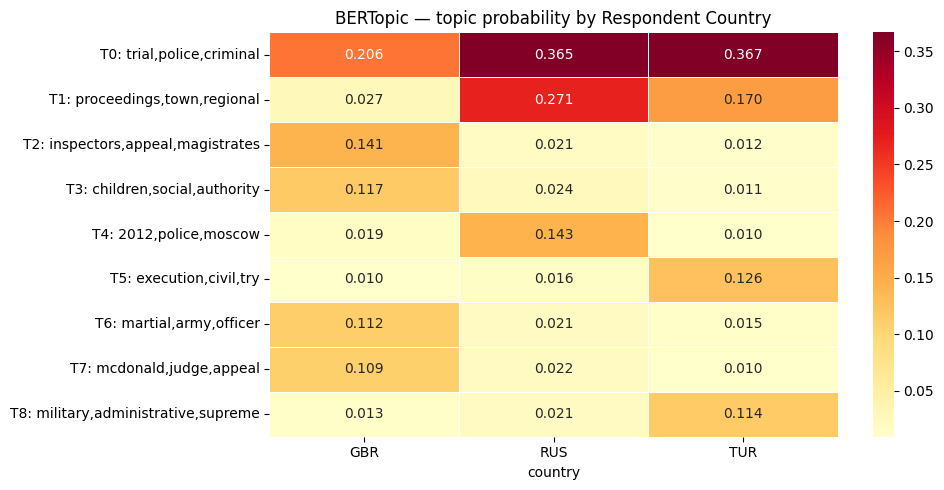

In [37]:
# ── BERTopic (optional) ───────────────────────────────────────────────────────
try:
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer
    from umap import UMAP
    from hdbscan import HDBSCAN
    from sklearn.feature_extraction.text import CountVectorizer as _CVec
    _BERTOPIC_OK = True
except ImportError:
    print('BERTopic deps missing. pip install bertopic sentence-transformers umap-learn hdbscan')
    _BERTOPIC_OK = False

if _BERTOPIC_OK:
    N_TOPICS_BT = 10
    _device_bt  = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Aggressive stopword list — prevents stop-word-heavy topics
    _BT_STOPS = list(LEGAL_STOP) + [
        'applicant','government','court','case','judgment','article','paragraph',
        'section','provided','pursuant','accordance','submitted','noted','stated',
        'alleged','complaint','application','convention','right','law','act',
        'made','would','could','given','also','said','see','whether','therefore',
        'however','may','shall','must','well','one','two','three','first','second',
    ]
    _bt_vec = _CVec(stop_words=_BT_STOPS, min_df=3, ngram_range=(1, 2))

    _bt = BERTopic(
        embedding_model=SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=_device_bt),
        umap_model=UMAP(n_neighbors=10, n_components=5, min_dist=0.0, metric='cosine', random_state=42),
        hdbscan_model=HDBSCAN(min_cluster_size=10, min_samples=5, metric='euclidean', prediction_data=True),
        vectorizer_model=_bt_vec,
        nr_topics=N_TOPICS_BT, calculate_probabilities=True, verbose=False,
    )
    _bt_ids, _bt_probs = _bt.fit_transform(df['text'].fillna('').tolist())
    _bt_probs = np.nan_to_num(np.array(_bt_probs, dtype=float), nan=0.0)
    if _bt_probs.ndim == 1:
        _bt_probs = _bt_probs.reshape(len(df), -1)

    _bt_topics = []
    print(f'BERTopic: {len(set(_bt_ids))-(1 if -1 in _bt_ids else 0)} topics | '
          f'outliers: {sum(1 for t in _bt_ids if t==-1)}\n')
    for tid in sorted(set(_bt_ids)):
        if tid == -1: continue
        ws = _bt.get_topic(tid)
        if not ws: continue
        top_words = [w for w, _ in ws[:12]]
        _bt_topics.append({'id': tid, 'top_words': top_words})
        print(f'  T{tid:<5}  {", ".join(top_words)}')

    if _bt_probs.shape[1] > 0 and _bt_topics:
        import seaborn as sns
        _bt_by_label = (pd.DataFrame(_bt_probs).assign(label=df['label'].values)
                        .groupby('label').mean().T)
        _bt_by_label.columns = ['No Violation', 'Violation']
        _bt_by_label['Δ (V−NV)'] = _bt_by_label['Violation'] - _bt_by_label['No Violation']
        _bt_by_label.index = [
            f"T{i}: {','.join(next((t['top_words'][:3] for t in _bt_topics if t['id']==i),[str(i)]))}"
            for i in _bt_by_label.index]
        _bt_by_label = _bt_by_label.sort_values('Δ (V−NV)', ascending=False)

        fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(_bt_by_label)*0.45)))
        sns.heatmap(_bt_by_label[['No Violation','Violation']], annot=True, fmt='.3f',
                    cmap='RdYlGn', ax=axes[0], linewidths=0.5)
        axes[0].set_title('BERTopic — topic weight by outcome')
        axes[1].barh(range(len(_bt_by_label)), _bt_by_label['Δ (V−NV)'],
                     color=['salmon' if v>0 else 'steelblue' for v in _bt_by_label['Δ (V−NV)']])
        axes[1].set_yticks(range(len(_bt_by_label)))
        axes[1].set_yticklabels(_bt_by_label.index, fontsize=8)
        axes[1].axvline(0, color='black', lw=0.8)
        axes[1].set_title('BERTopic — topic skew toward Violation')
        plt.tight_layout(); plt.show()

        # NMF vs BERTopic comparison
        print('\n=== NMF vs BERTopic: violation-skewed topics ===')
        print('NMF (deterministic, sparse, TF-IDF weights):')
        for idx, row in _nmf_by_label[_nmf_by_label['Δ (V−NV)']>0].iterrows():
            print(f'  Δ={row["Δ (V−NV)"]:.4f}  {idx}')
        print('\nBERTopic (semantic embeddings, cluster-based):')
        for idx, row in _bt_by_label[_bt_by_label['Δ (V−NV)']>0].iterrows():
            print(f'  Δ={row["Δ (V−NV)"]:.4f}  {idx}')
        print('\nNMF: more interpretable weights, deterministic, sparser.')
        print('BERTopic: captures multi-word concepts, but sensitive to UMAP random state.')

        _bt_by_country = (pd.DataFrame(_bt_probs).assign(country=df['respondent'].values)
                          .groupby('country').mean().T)
        _bt_by_country.index = [
            f"T{i}: {','.join(next((t['top_words'][:3] for t in _bt_topics if t['id']==i),[str(i)]))}"
            for i in _bt_by_country.index]
        fig, ax = plt.subplots(figsize=(10, max(5, len(_bt_by_country)*0.5)))
        sns.heatmap(_bt_by_country, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, linewidths=0.5)
        ax.set_title('BERTopic — topic probability by Respondent Country')
        plt.tight_layout(); plt.show()


## 13. Summary

In [38]:
print('=' * 65)
print(f'FINAL RESULTS  --  {cfg["label"]}')
print('=' * 65)
for r in sorted(all_results, key=lambda x: x['Macro-F1'], reverse=True):
    print(f'  {r["Model"]:<38} {str(r["Tokens"]):>5} tok   macro-F1 = {r["Macro-F1"]:.3f}')

print()
print('KEY FINDINGS')
print('-' * 65)
print('1. SVM @ 512 tok ~= LegalBERT 512 fine-tuned (same input, same performance).')
print('   The apparent SVM advantage was truncation, not model quality.')
print()
print('2. SVM scales with token budget:')
for r in coverage_results:
    print(f'   {r["Budget"]:>10}: {r["Macro-F1"]:.3f}')
print()
print('3. LegalBERT chunked 4x (2040 tok) beats full-text SVM via')
print('   coverage restoration + domain pretraining.')
print()
print('4. Per-country F1 in some countries tracks violation rate,')
print('   consistent with base-rate exploitation alongside genuine signal.')
print()
print('5. Masking country/place/month tokens has limited impact —')
print('   the correlational information is distributed, not concentrated.')
print()
if longformer_f1 is not None or neobert_f1 is not None:
    print('6. Long-context models (4096 tok) with single-vector classification')
    print('   (Legal-Longformer CLS, NeoBERT CLS) score ~0.69 — well below')
    print('   LegalBERT chunked mean-pool (0.752+). The bottleneck is')
    print('   single-vector vs chunked multi-CLS pooling, not context length.')


FINAL RESULTS  --  Original (436 Art.6 cases, RUS/TUR/GBR)
  LegalBERT chunked 4x                    2040 tok   macro-F1 = 0.765
  TF-IDF + SVM (2048 tok)                 2048 tok   macro-F1 = 0.731
  TF-IDF + LogReg (full)                  Full tok   macro-F1 = 0.721
  TF-IDF + SVM (full)                     Full tok   macro-F1 = 0.718
  TF-IDF + SVM (1024 tok)                 1024 tok   macro-F1 = 0.701
  LegalBERT 512-tok                        512 tok   macro-F1 = 0.688
  TF-IDF + SVM (512 tok)                   512 tok   macro-F1 = 0.674
  Dummy (majority class)                   N/A tok   macro-F1 = 0.423

KEY FINDINGS
-----------------------------------------------------------------
1. SVM @ 512 tok ~= LegalBERT 512 fine-tuned (same input, same performance).
   The apparent SVM advantage was truncation, not model quality.

2. SVM scales with token budget:
      512 tok: 0.674
     1024 tok: 0.701
     2048 tok: 0.731
    Full text: 0.718

3. LegalBERT chunked 4x (2040 tok) beats